In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px  # Import thêm thư viện vẽ bản đồ


%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


## 1. Basic analysis of data & EDA


World Development Indicators (WDI) is the World Bank's premier compilation of cross-country, comparable statistics on development, covering over 1,600 indicators for 217 economies

WDI is currently organized according to thematic areas: Poverty and Inequality, People, Economy, etc

**Big goal**: In the context of global integration, how can Viet Nam effectively leverage investments in education and healthcare to improve labor market outcomes, while addressing gender imbalance and ensuring equitable opportunities for women in the 25-year period, starting from 2000?

### Dataset structure

**Rows:** Each row corresponds to a country for the `SE.TER.ENRR` indicator over the years.  
**Columns:**
| Field | Description |
|---|---|
| `Country Name` | Country name |
| `Country Code` | Country code  |
| `Series Name` | Indicator name |
| `Series Code` | Indicator code |
| `2000 [YR2000] … 2024 [YR2024]` | Indicator value per year |

In addition to the main data rows, there are footer/metadata rows at the end of the file which will be removed during the cleaning step.

In [3]:
# Dataset path
import os
DATA_PATH = 'data/dataset.csv'

# # List of target countries and indicators (easy to extend)
# COUNTRY_WHITELIST = [
#     'VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'JPN', 'KOR',
#     'DEU', 'FRA', 'GBR', 'SWE', 'USA', 'CAN', 'BRA', 'MEX', 'ZAF', 'NGA'
# ]

# SERIES_WHITELIST = [
#     'SE.TER.ENRR',
#     'SL.UEM.TOTL.ZS',
#     'SL.SRV.EMPL.ZS',
#     'SG.GEN.PARL.ZS',
#     'SE.XPD.TOTL.GD.ZS',
#     'SH.XPD.GHED.GE.ZS',
#     'NY.GDP.PCAP.CD'
# ]

try:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

df = df_raw.drop_duplicates(subset=["Country Code", "Series Code"])
print(f"Initial size: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")

Initial size: 1848 rows x 29 columns

Column names:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


### Basic statistics

#### Descriptive statistics

Explore data: count, std, min, max, quartiles

In [4]:
# Get list of year columns in WDI format and limit to 2000-2024
year_cols = [
    c for c in df.columns
    if c.startswith('20') and c.endswith(']') and int(c[:4]) >= 2000 and int(c[:4]) <= 2024
]
year_cols = sorted(year_cols, key=lambda x: int(x[:4]))

print(f"Number of years with data: {len(year_cols)} (from {year_cols[0]} to {year_cols[-1]})")

# Convert to numeric
df_years = df[year_cols].apply(pd.to_numeric, errors='coerce')
# print(f"\nDescriptive Statistics:\n{df_years.describe().round(3)}")

# Detailed statistics for each indicator
for i, row in df.iterrows():
    vals = pd.to_numeric(row[year_cols], errors='coerce')
    print(f"   Series Code : {row['Series Code']}")
    print(f"   Count  : {vals.count()} / {len(year_cols)} years with data")
    print(f"   Mean   : {vals.mean():.4f}")
    print(f"   Std    : {vals.std():.4f}")
    print(f"   Min    : {vals.min():.4f}")
    print(f"   Max    : {vals.max():.4f}")
    print(f"   25%    : {vals.quantile(0.25):.4f}")
    print(f"   50%    : {vals.quantile(0.50):.4f}")
    print(f"   75%    : {vals.quantile(0.75):.4f}")


Number of years with data: 25 (from 2000 [YR2000] to 2024 [YR2024])
   Series Code : NY.GDP.PCAP.CD
   Count  : 24 / 25 years with data
   Mean   : 415.4949
   Std    : 162.2467
   Min    : 138.7068
   Max    : 651.4171
   25%    : 269.2100
   50%    : 432.9058
   75%    : 534.2577
   Series Code : SE.TER.ENRR
   Count  : 7 / 25 years with data
   Mean   : 5.6626
   Std    : 4.0151
   Min    : 1.3743
   Max    : 10.8544
   25%    : 2.5388
   50%    : 3.9382
   75%    : 9.1968
   Series Code : SE.TER.ENRR.FE
   Count  : 7 / 25 years with data
   Mean   : 2.6966
   Std    : 2.1549
   Min    : 0.5714
   Max    : 5.9365
   25%    : 1.0131
   50%    : 1.8253
   75%    : 4.2585
   Series Code : SE.XPD.TOTL.GD.ZS
   Count  : 8 / 25 years with data
   Mean   : 3.6048
   Std    : 0.6115
   Min    : 2.6042
   Max    : 4.5440
   25%    : 3.4048
   50%    : 3.4707
   75%    : 3.8572
   Series Code : SG.GEN.PARL.ZS
   Count  : 16 / 25 years with data
   Mean   : 27.5555
   Std    : 0.2695
   Min   

### Missing values

In [5]:
# ── % Missing Values ──
total_cells = df_years.size           # rows x years
total_missing = df_years.isnull().sum().sum()
overall_pct = round(total_missing / total_cells * 100, 2)

print(f"\nOverview:")
print(f"   Total data cells : {total_cells}")
print(f"   Missing cells    : {total_missing}")
print(f"   Missing rate     : {overall_pct}%")

# By INDICATOR (row)
missing_per_row  = df_years.isnull().sum(axis=1)
pct_per_row      = (missing_per_row / len(year_cols) * 100).round(2)

# By YEAR (column)
missing_per_col  = df_years.isnull().sum()
pct_per_col      = (missing_per_col / len(df_years) * 100).round(2)

print(f"\nBy INDICATOR (row):")
for i, row in df.iterrows():
    n = missing_per_row.iloc[i]
    p = pct_per_row.iloc[i]
    short_name = str(row['Series Name'])[:60]
    print(f"   {short_name} ... | Missing: {n}/{len(year_cols)} years ({p}%)")
for col, n, p in zip(year_cols, missing_per_col, pct_per_col):
    bar = " " * int(p // 5) if p > 0 else ""
    print(f"   {col} | Missing: {n}/{len(df_years)} indicators ({p}%) {bar}")




Overview:
   Total data cells : 46200
   Missing cells    : 10395
   Missing rate     : 22.5%

By INDICATOR (row):
   GDP per capita (current US$) ... | Missing: 1/25 years (4.0%)
   School enrollment, tertiary (% gross) ... | Missing: 18/25 years (72.0%)
   School enrollment, tertiary, female (% gross) ... | Missing: 18/25 years (72.0%)
   Government expenditure on education, total (% of GDP) ... | Missing: 17/25 years (68.0%)
   Proportion of seats held by women in national parliaments (% ... | Missing: 9/25 years (36.0%)
   Domestic general government health expenditure (% of GDP) ... | Missing: 3/25 years (12.0%)
   Domestic general government health expenditure (% of general ... | Missing: 3/25 years (12.0%)
   Female share of employment in senior and middle management ( ... | Missing: 22/25 years (88.0%)
   Employment in services (% of total employment) (modeled ILO  ... | Missing: 0/25 years (0.0%)
   Labor force with advanced education, female (% of female wor ... | Missing: 2

## 2. Analysis objectives

---

### Objective 1: Compare trends and the level of national budget priority for education

### Analysis Objectives
The purpose is to evaluate the level of **government investment in education** through **public education expenditure as a percentage of GDP** to capture the **overall trend and relative commitment of governments to education funding**, thereby providing insight into how education investment evolves over time across different countries.

This objective is based on the variable `SE.XPD.TOTL.GD.ZS` and `NY.GDP.PCAP.CD`, using **data from 12 countries** over the period **2015–2022**. 
### Metrics

`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total 
- This indicator measures total government spending  on education, expressed as a percentage of GDP.
- **Calculation method:** [Total public expenditure on education at all levels] / [GDP] x 100
- This indicator reflects the level of government commitment and priority toward education development relative to the size of the economy.
- **Note:** Only includes **public expenditure** (state budget), excluding private spending .

`NY.GDP.PCAP.CD` – **GDP per capita (current US$)**  
- This indicator measures the **average economic output per person**, expressed in current US dollars.  
- **Calculation method:** [GDP] / [Total population]  
- It is used to **classify countries into different income groups** (e.g., high, upper-middle, lower-middle income).  

### Reason for selecting metrics

The variable `SE.XPD.TOTL.GD.ZS` is selected because it is **standardized by economic size**, allowing fair comparisons between countries.  

Meanwhile, `NY.GDP.PCAP.CD` is used to **group countries by income level**, enabling the analysis to compare how education expenditure differs across **different stages of economic development**.  

This grouping helps reveal whether countries at similar income levels exhibit similar patterns in **education investment behavior**.

In [6]:
df_raw_full = df_raw

# List of indicators needed for Topic 1 / Education Investment and Access
EDU_INDICATORS = [
    'NY.GDP.PCAP.CD',
    'SE.TER.ENRR',
    'SE.XPD.TOTL.GD.ZS'
]

# Select 12 countries based on the original Topic 1 list
SELECTED_COUNTRIES = ['BRA', 'FRA', 'DEU', 'IND', 'IDN', 'JPN', 'KOR', 'SGP', 'ZAF', 'GBR', 'USA', 'VNM']

# 2. Data preprocessing: Select required columns (also filter for years 2015-2022 in Wide format)
year_cols = [f"{year} [YR{year}]" for year in range(2015, 2023)]
base_cols = ['Country Name', 'Country Code', 'Series Name', 'Series Code']

# Filter dataset (indicators, countries, and years)
df_raw = df_raw_full[
    (df_raw_full['Series Code'].isin(EDU_INDICATORS)) & 
    (df_raw_full['Country Code'].isin(SELECTED_COUNTRIES))
][base_cols + year_cols].copy()

# Convert from Wide to Long format
df_long = df_raw.melt(
    id_vars=base_cols,
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)

# Extract year number (e.g., "2015 [YR2015]" -> 2015)
df_long['Year'] = df_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
df_long = df_long.sort_values(by=['Country Code', 'Series Code', 'Year']).reset_index(drop=True)

df_clean_edu = df_long.copy()
df_clean_edu['Value'] = df_clean_edu.groupby(['Country Code', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

In [7]:
# 3. Detailed check for missing data
missing_detail = df_long[df_long['Value'].isna()][['Country Name', 'Series Code', 'Year']]
if len(missing_detail) > 0:
    print("Missing data cells (NaN):")
    print(missing_detail.to_string(index=False))
else:
    print("No missing data found.")

# 4. Handle missing data using linear interpolation within each (country, indicator) group
df_clean = df_long.copy()
df_clean['Value'] = df_clean.groupby(['Country Code', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

print(f"Number of missing values after processing: {df_clean['Value'].isna().sum()}")

Missing data cells (NaN):
  Country Name       Series Code  Year
        France SE.XPD.TOTL.GD.ZS  2015
        France SE.XPD.TOTL.GD.ZS  2016
United Kingdom SE.XPD.TOTL.GD.ZS  2022
         Japan SE.XPD.TOTL.GD.ZS  2022
     Singapore       SE.TER.ENRR  2015
 United States SE.XPD.TOTL.GD.ZS  2022
      Viet Nam       SE.TER.ENRR  2018
      Viet Nam       SE.TER.ENRR  2020
Number of missing values after processing: 0


---
## Preprocessing for Objectives 1, 2, 3
### Handling Missing Data

In the dataset, the group identified some missing values (NaN) scattered throughout, for example:

- Missing **education expenditure (% GDP)** in France (2015–2016), United Kingdom (2022), Japan (2022), United States (2022)  
- Missing **tertiary enrollment rate** in Singapore (2015) and Viet Nam (2018, 2020)

### Processing Method

The group used **_linear interpolation_** for each *(country, indicator)* to fill in the missing values.

### Reason for Selection

- **_Time-series data_** → the indicators change quite **smoothly over time**, so values can be estimated based on neighboring years  
- **_Very small missing rate_** (8/288) → does not significantly affect the overall trend  
- **_Local missing data_** → each country/indicator is missing only in **a few individual years (maximum 2 years)**, with no long consecutive gaps  
- **_Data retention_** → avoids dropping rows, ensuring sufficient data for visualization and analysis  

### Limitations

Interpolation is only an **_estimation_**, so it may slightly deviate from actual values. However, since the missing data is minimal and not continuous, the group considers this impact to be **negligible**.

---
#### Charts

Chart 1: Line Chart — Trend of Education Expenditure (% of GDP) Over the Years

- **Reason for choosing a Line Chart:**  
    Line Chart is the most standard format for tracking **time-series data**. It allows easy comparison of:
    - Slope (rate of change) between countries
    - Relative position (which country invests more)
    - Overall trend: increasing, decreasing, or stable
    - Our team used **highlight Min/Max** on each line to emphasize the country with the highest and lowest investment at each point in time.

Chart 2: Boxplot — Distribution of Education Expenditure by Income Group
- **Reason for choosing a Boxplot:**  
    - Boxplot helps visualize **distribution boundaries, standard deviation, median, and outlier investment levels** for each income group. Examining by income group instead of individual countries allows us to assess the degree of disparity in education investment and how the economy influences this distribution.

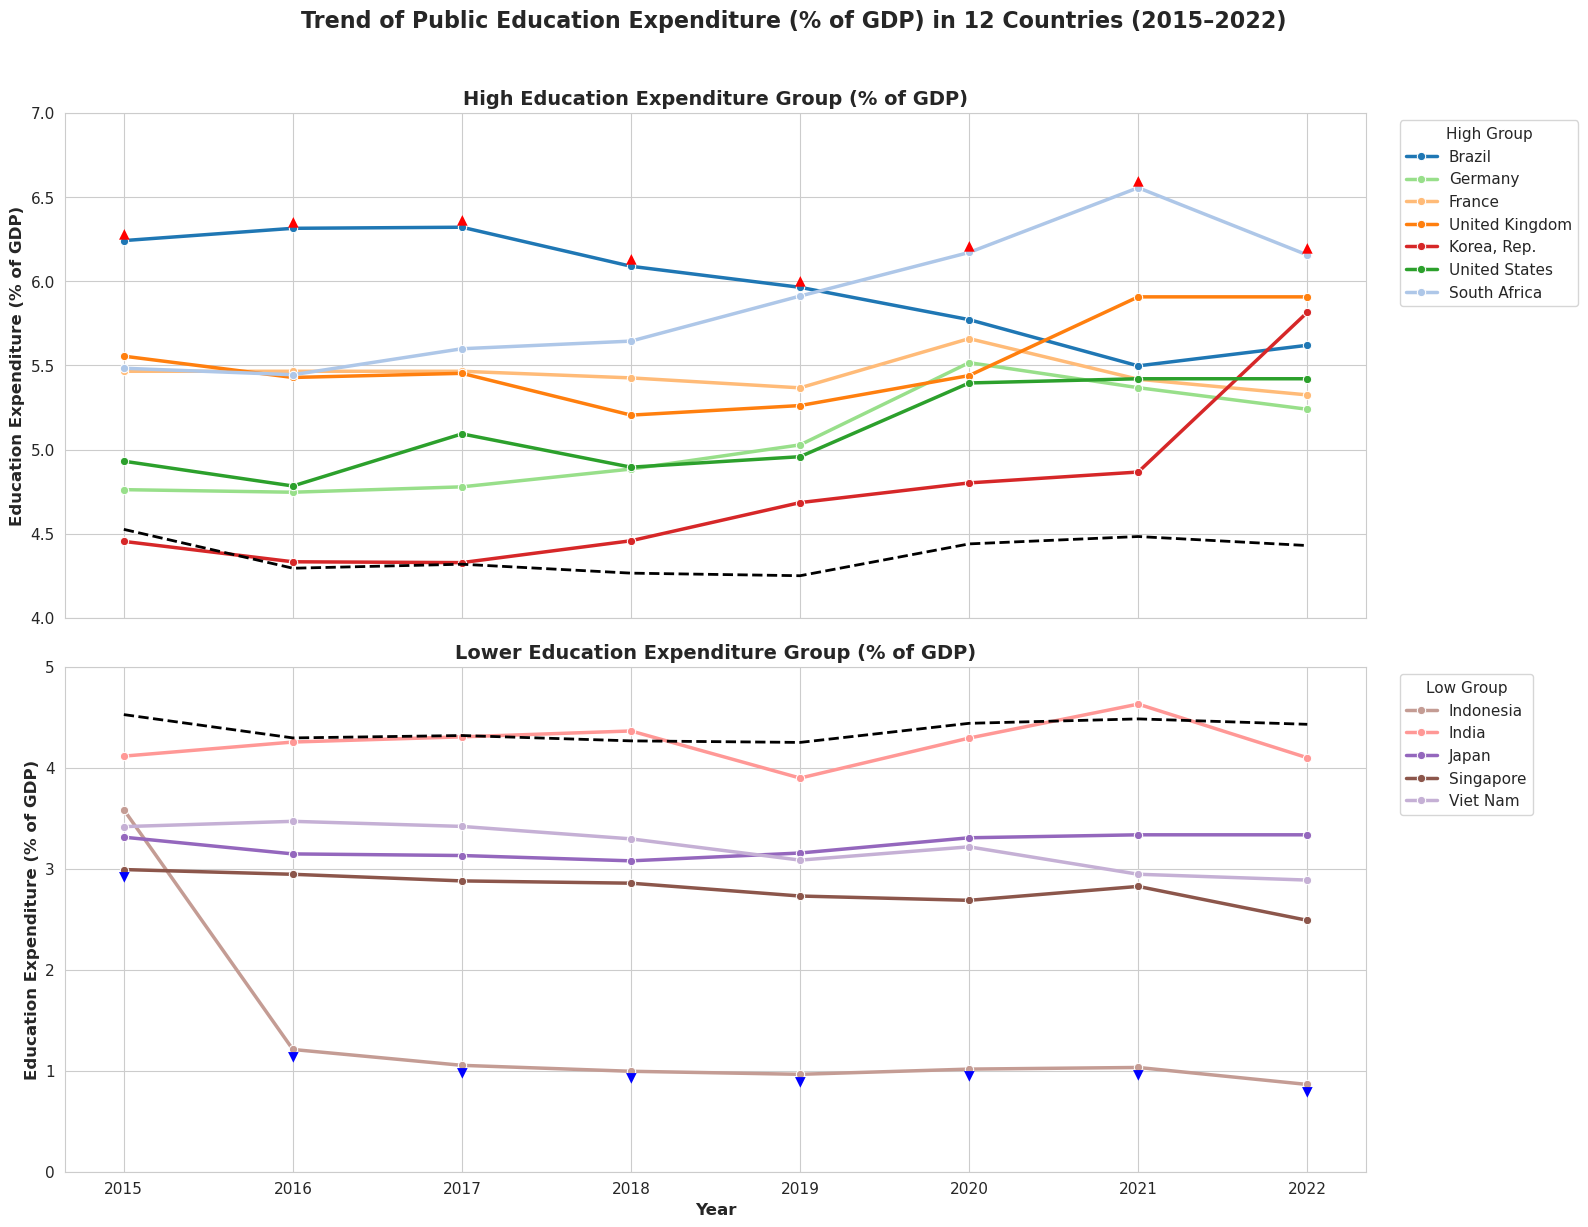

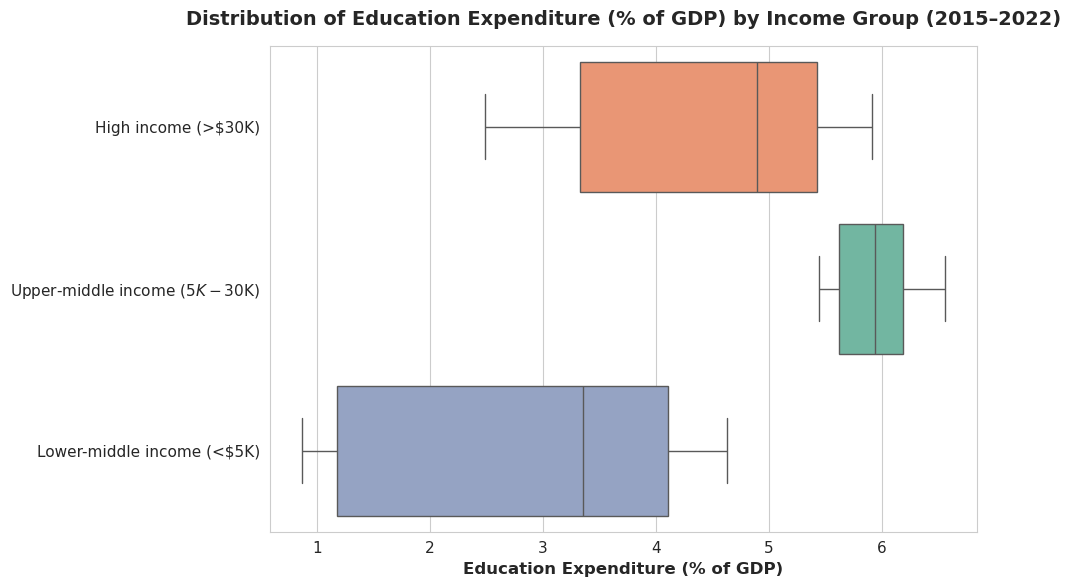


Income group table:
  Singapore            | Average GDP/capita: $67,311 | Group: High income (>$30K)
  United States        | Average GDP/capita: $63,934 | Group: High income (>$30K)
  Germany              | Average GDP/capita: $47,157 | Group: High income (>$30K)
  United Kingdom       | Average GDP/capita: $43,732 | Group: High income (>$30K)
  France               | Average GDP/capita: $39,765 | Group: High income (>$30K)
  Japan                | Average GDP/capita: $38,441 | Group: High income (>$30K)
  Korea, Rep.          | Average GDP/capita: $33,685 | Group: High income (>$30K)
  Brazil               | Average GDP/capita: $8,814 | Group: Upper-middle income ($5K-$30K)
  South Africa         | Average GDP/capita: $6,347 | Group: Upper-middle income ($5K-$30K)
  Indonesia            | Average GDP/capita: $3,931 | Group: Lower-middle income (<$5K)
  Viet Nam             | Average GDP/capita: $3,290 | Group: Lower-middle income (<$5K)
  India                | Average GDP/capita: 

In [8]:
# ====== CHART 1: LINE CHART — Education Expenditure (% of GDP) ======

# Filter education expenditure data
edu_df = df_clean_edu[df_clean_edu['Series Code'] == 'SE.XPD.TOTL.GD.ZS'].copy()

# Tách thành 2 nhóm dựa trên giá trị trung bình để đường không bị chồng chéo
avg_exp = edu_df.groupby('Country Name')['Value'].mean().sort_values(ascending=False)

# Chuyển thủ công Hàn Quốc (Korea, Rep.) lên nhóm High theo yêu cầu
high_exp_countries = list(avg_exp.index[:6])
if 'Korea, Rep.' not in high_exp_countries:
    high_exp_countries.append('Korea, Rep.')
    
low_exp_countries = [c for c in avg_exp.index if c not in high_exp_countries]

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

palette = sns.color_palette('tab20', n_colors=len(edu_df['Country Name'].unique()))
color_map = dict(zip(avg_exp.index, palette))

# Vẽ nhóm chi tiêu cao
sns.lineplot(
    data=edu_df[edu_df['Country Name'].isin(high_exp_countries)],
    x='Year', y='Value', hue='Country Name',
    marker='o', markersize=6, linewidth=2.5, palette=color_map, ax=axes[0]
)
axes[0].set_title('High Education Expenditure Group (% of GDP)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='High Group')
axes[0].set_ylim(4, 7)

# Vẽ nhóm chi tiêu thấp
sns.lineplot(
    data=edu_df[edu_df['Country Name'].isin(low_exp_countries)],
    x='Year', y='Value', hue='Country Name',
    marker='o', markersize=6, linewidth=2.5, palette=color_map, ax=axes[1]
)
axes[1].set_title('Lower Education Expenditure Group (% of GDP)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Low Group')
axes[1].set_ylim(0, 5)

# Highlight Min/Max for each year (Global)
for year in edu_df['Year'].unique():
    year_data = edu_df[edu_df['Year'] == year]
    max_row = year_data.loc[year_data['Value'].idxmax()]
    min_row = year_data.loc[year_data['Value'].idxmin()]
    
    # Max trên biểu đồ 1
    axes[0].annotate('▲', xy=(max_row['Year'], max_row['Value']),
                     fontsize=10, color='red', ha='center', va='bottom')
    # Min trên biểu đồ 2
    axes[1].annotate('▼', xy=(min_row['Year'], min_row['Value']),
                     fontsize=10, color='blue', ha='center', va='top')

# Overall mean line cho từng cụm
overall_mean = edu_df.groupby('Year')['Value'].mean()
axes[0].plot(overall_mean.index, overall_mean.values, color='black', linestyle='--', linewidth=2, label='Mean of 12 countries', zorder=10)
axes[1].plot(overall_mean.index, overall_mean.values, color='black', linestyle='--', linewidth=2, label='Mean of 12 countries', zorder=10)

plt.xticks(range(2015, 2023))
plt.suptitle('Trend of Public Education Expenditure (% of GDP) in 12 Countries (2015–2022)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ====== CHART 2: BOXPLOT — Education Expenditure Distribution ======

# Group by income level (based on average GDP per capita)
gdp_df = df_clean_edu[df_clean_edu['Series Code'] == 'NY.GDP.PCAP.CD'].copy()
gdp_mean = gdp_df.groupby('Country Name')['Value'].mean().reset_index()
gdp_mean.columns = ['Country Name', 'GDP_Mean']

# Income group classification: High (>30000), Upper-middle (5000-30000), Lower-middle (<5000)
def classify_income(gdp):
    if gdp >= 30000:
        return 'High income (>$30K)'
    elif gdp >= 5000:
        return 'Upper-middle income ($5K-$30K)'
    else:
        return 'Lower-middle income (<$5K)'

gdp_mean['Income_Group'] = gdp_mean['GDP_Mean'].apply(classify_income)

# Merge income group into education data
edu_boxplot = edu_df.merge(gdp_mean[['Country Name', 'Income_Group']], on='Country Name', how='left')

plt.figure(figsize=(10, 6))

# Boxplot by income group
group_order = ['High income (>$30K)', 'Upper-middle income ($5K-$30K)', 'Lower-middle income (<$5K)']
sns.boxplot(data=edu_boxplot, y='Income_Group', x='Value', order=group_order,
            palette='Set2', hue='Income_Group', dodge=False, legend=False)
plt.title('Distribution of Education Expenditure (% of GDP) by Income Group (2015–2022)',
                  fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Print income group table
print("\nIncome group table:")
for _, row in gdp_mean.sort_values('GDP_Mean', ascending=False).iterrows():
    print(f"  {row['Country Name']:20s} | Average GDP/capita: ${row['GDP_Mean']:,.0f} | Group: {row['Income_Group']}")

**Line Chart Analysis:**

**A. Overall Trend:**

Education expenditure as a percentage of GDP is generally **relatively stable** during 2015–2022, with most countries showing only **slight fluctuations** over the years. However, **Indonesia is an exception**, with a sharp and noticeable decrease compared to other countries.
--> This indicates that education spending is usually a **stable budget item**, with little short-term volatility, and large changes (like in Indonesia) should be carefully considered in context or measurement methods.

**B. High Education Expenditure Group (above 4.5% of GDP)**

- **Brazil** maintains high expenditure (~5.5–6.3%) but shows a **slight decreasing trend**, suggesting that despite previously prioritizing education, the country may be under **fiscal pressure** or reallocating budget to other sectors.  

- **South Africa** not only maintains a high level (~5.4–6.6%) but also shows a **gradual increase**, indicating that education is becoming a **long-term policy focus**, especially as the country seeks to improve workforce quality.  

- **France, United Kingdom, Germany, United States** remain **stable around 4.7–5.5%**, reflecting a common feature of developed economies:  
  --> **education spending has reached a “balanced” state**, where the government maintains stable investment as the education system is relatively mature.

- **Korea (South Korea)** shows a **marked increase** over time, standing out compared to other developed countries.  
  --> This indicates that the country is still in a phase of **reflecting continued policy emphasis on strengthening human capital**, even though it has reached a high level of development.  

---

**C. Lower Education Expenditure Group (below 4.5% of GDP)**

- **India** (~3.9–4.6%) maintains a low-to-medium level but is fairly stable, indicating that as a populous country, expanding education may face **budgetary constraints**.  

- **Viet Nam** (~2.9–3.5%) shows a slight decreasing trend, suggesting that the growth rate of education spending **has not kept pace with economic growth**, or resources are being allocated to other development areas.  

- **Japan** (~3.1–3.3%) remains low among developed countries, indicating that the education system may **indicate a relatively greater role of private spending in education** rather than public expenditure.  

- **Singapore** (~2.5–3%) has the lowest expenditure as % of GDP among developed countries. However, due to high per capita income, the actual amount spent on education is still significant.  
--> This shows that each country allocates its budget differently, and % of GDP does not always fully reflect investment levels.  

- **Indonesia** sharply decreases from ~3.6% to ~1% and maintains a low level, indicating a significant change in budget allocation or statistical methodology.  

---

**D. COVID-19 Impact (2020)**

Some countries such as **Germany, South Africa, and United Kingdom** recorded slight increases in 2020. However, this rise **does not necessarily reflect actual increased spending**, but may result from **GDP decline during COVID-19**, which caused the expenditure ratio (% of GDP) to increase.

---

### Objective 2: Measure the growth rate of tertiary education access

### Analysis Objectives

The purpose is to evaluate the level of **access to tertiary education** through the **tertiary enrollment rate**, in order to capture the **extent to which higher education has expanded over time** across different countries.

This objective is based on the variable `SE.TER.ENRR`, using **data from 12 countries** and measuring the **absolute and relative growth between 2015 and 2022**, with interpolation applied where necessary to ensure data continuity.

### Metrics

`SE.TER.ENRR` - School enrollment, tertiary (% gross)
- This indicator measures the **gross enrollment ratio for tertiary education (% gross)**, i.e., [Number of students enrolled in tertiary education regardless of age] / [Population of official tertiary school-age] × 100.
- The value **can exceed 100%** when there are many over-age students .
- Reason choosing metrics: The indicator reflects a country's **level of tertiary education access**.

### Charts

**Chart: Dumbbell Plot**

- **Reason for choosing Dumbbell Plot:**
Instead of using a Line Chart for this goal the **Dumbbell Plot** is excellent for visualizing the **gap** between two points in time — Starting Point A (2015) and Ending Point B (2022). Viewers can immediately see which country has the longest "line" = the strongest breakthrough.


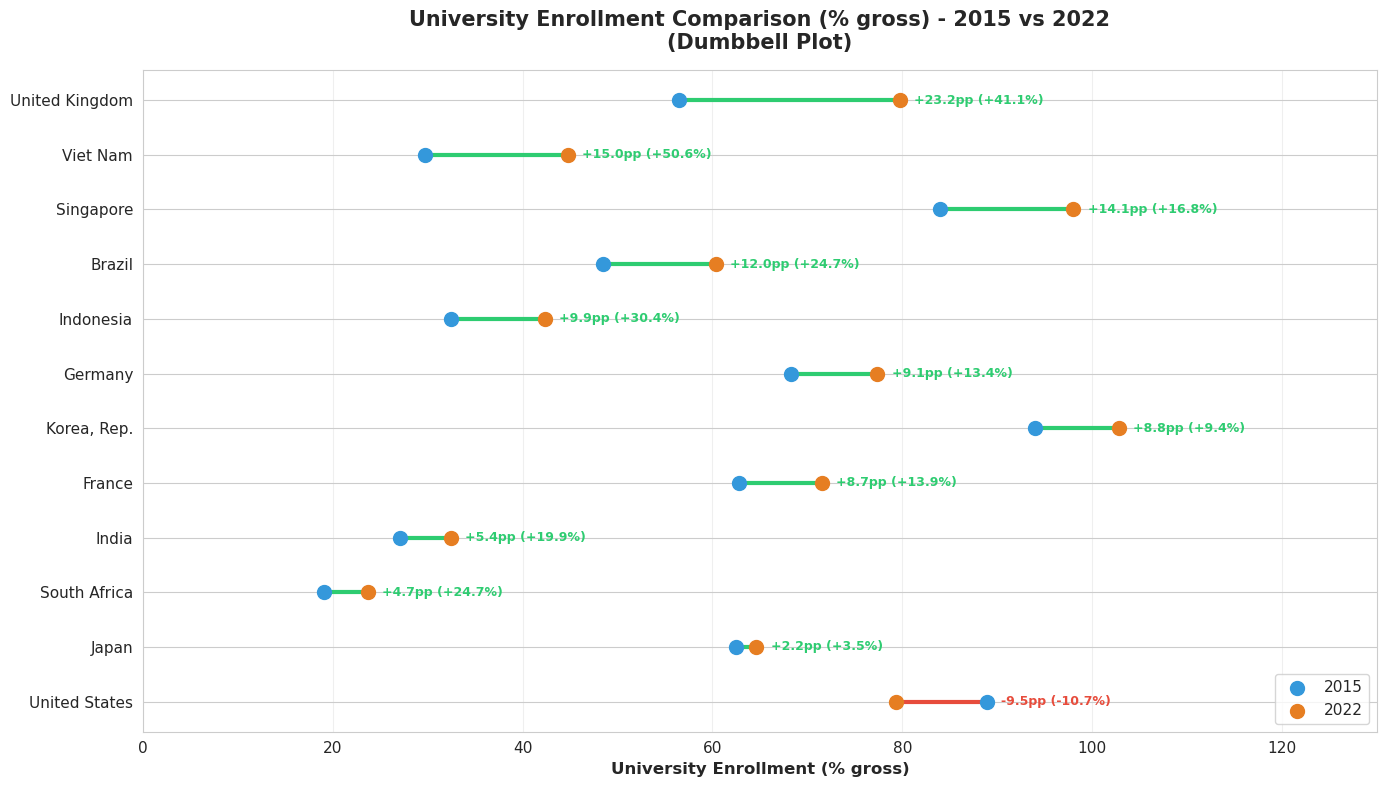


Top 5 countries with the highest growth rate (absolute change):
  United Kingdom       | 2015: 56.5% → 2022: 79.7% | Change: +23.2pp (+41.1%)
  Viet Nam             | 2015: 29.7% → 2022: 44.8% | Change: +15.0pp (+50.6%)
  Singapore            | 2015: 83.9% → 2022: 98.0% | Change: +14.1pp (+16.8%)
  Brazil               | 2015: 48.4% → 2022: 60.4% | Change: +12.0pp (+24.7%)
  Indonesia            | 2015: 32.5% → 2022: 42.3% | Change: +9.9pp (+30.4%)


In [9]:
# ====== CHART 2: DUMBBELL PLOT — University Enrollment Growth 2015 vs 2022 ======

ter_df = df_clean_edu[df_clean_edu['Series Code'] == 'SE.TER.ENRR'].copy()

# Get values for 2015 and 2022
ter_2015 = ter_df[ter_df['Year'] == 2015][['Country Name', 'Value']].rename(columns={'Value': 'Y2015'})
ter_2022 = ter_df[ter_df['Year'] == 2022][['Country Name', 'Value']].rename(columns={'Value': 'Y2022'})
dumbbell = ter_2015.merge(ter_2022, on='Country Name')
dumbbell['Change'] = dumbbell['Y2022'] - dumbbell['Y2015']
dumbbell['Change_pct'] = (dumbbell['Change'] / dumbbell['Y2015']) * 100
dumbbell = dumbbell.sort_values('Change', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))

# Draw connecting lines
for i, row in dumbbell.iterrows():
    color = '#2ecc71' if row['Change'] >= 0 else '#e74c3c'
    ax.plot([row['Y2015'], row['Y2022']], [i, i], color=color, linewidth=3, zorder=1)

# Draw points for 2015 and 2022
ax.scatter(dumbbell['Y2015'], range(len(dumbbell)), color='#3498db', s=100, zorder=2, label='2015')
ax.scatter(dumbbell['Y2022'], range(len(dumbbell)), color='#e67e22', s=100, zorder=2, label='2022')

# Annotate changes
for i, row in dumbbell.iterrows():
    sign = '+' if row['Change'] >= 0 else ''
    ax.annotate(f"{sign}{row['Change']:.1f}pp ({sign}{row['Change_pct']:.1f}%)",
                xy=(max(row['Y2015'], row['Y2022']) + 1.5, i),
                fontsize=9, va='center',
                color='#2ecc71' if row['Change'] >= 0 else '#e74c3c',
                fontweight='bold')

ax.set_yticks(range(len(dumbbell)))
ax.set_yticklabels(dumbbell['Country Name'], fontsize=11)
ax.set_xlabel('University Enrollment (% gross)', fontsize=12, fontweight='bold')
ax.set_title('University Enrollment Comparison (% gross) - 2015 vs 2022\n(Dumbbell Plot)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 130)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed table
print("\nTop 5 countries with the highest growth rate (absolute change):")
top5 = dumbbell.sort_values('Change', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['Country Name']:20s} | 2015: {row['Y2015']:.1f}% → 2022: {row['Y2022']:.1f}% | Change: +{row['Change']:.1f}pp (+{row['Change_pct']:.1f}%)")


#### Conclusion
1. Top countries with the strongest growth

- **United Kingdom** has the largest absolute increase (~+23pp), from ~56% to ~80%, indicating a significant expansion of the tertiary education system.

- **Viet Nam** shows a notable increase (~+15pp, ~+50%), ranking among the fastest-growing countries.
  --> This reflects efforts to expand access to higher education in a developing country.

- **Brazil**, **Indonesia**, **India** also record relatively large increases (~5-12pp), showing the trend of **expanding tertiary education** in developing countries.

2. Countries with very high enrollment rates

- **Korea (South Korea)** and **Singapore** maintain very high levels  and continue to increase.
  --> This indicates that higher education has **almost reached universal coverage**.

3. Special cases

- **United States** is the only country showing a **decline** (~-9.5pp), from ~89% to ~79%.
  --> This may reflect the high cost of college education, leading to a trend of seeking alternative paths .

4. General trend

- Developing countries  are growing faster, showing a trend of **narrowing the gap in higher education access** compared to developed countries.

- However, despite rapid growth, current tertiary enrollment rates are still significantly lower than countries that have achieved high universal coverage.

5. Insight for Viet Nam

- Viet Nam is among the countries with **rapid growth in tertiary enrollment**, indicating that policies to expand education have been effective.

- However, the absolute level (~45%) is still low compared to developed countries (70-100%).
  --> This shows that Viet Nam is in the **scale-up phase**, not yet reaching universal coverage.

  --> In the coming period, Viet Nam needs to:
  - Continue to **expand access to higher education**
  - Meanwhile, focus on **improving education quality**, avoiding chasing quantity alone


---

### Objective 3: Analyze the linear correlation between education investment and education access

### Analysis Objectives

To measure and analyze the degree of **correlation** between **average education expenditure as a percentage of GDP** and the **average tertiary enrollment rate** on a **multi-country scale** over the period **2015–2022**. This approach uses **averaged values** to capture the overall investment level and access performance of each country.

This objective is set to test the hypothesis: *"Do countries that allocate a higher share of GDP to education, on average, tend to achieve higher levels of access to tertiary education?"*

### Metrics

`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total 
- This indicator measures total government spending on education as a percentage of GDP, reflecting government commitment to education development relative to the size of the economy.
- Only includes **public expenditure**, excluding private spending.

`SE.TER.ENRR` - School enrollment, tertiary (% gross)
- Gross tertiary enrollment ratio (% gross).
- Reflects a country's **level of tertiary education access**.

### Charts


**Reason for choosing the chart:**
- To demonstrate correlation and tell a direct data story, **Scatter Plot** is graphically superior to a Combo Chart. Plotting 12 countries via bars and lines on dual axes heavily taxes the viewer's working memory. 
By assigning coordinates (Expenditure mapping to the X-axis, Enrollment mapping to the Y-axis), the mathematical relationship becomes instantly obvious at a glance: 
    - The addition of a **Trendline** visually proves that the correlation is weak (the line is nearly flat, points are dispersed).
    - Dividing the chart into **four target quadrants** via Median thresholds creates an immediate storytelling matrix: Who spends smartly? Who struggles? And most importantly, exactly where does **Vietnam** stand in the global layout?


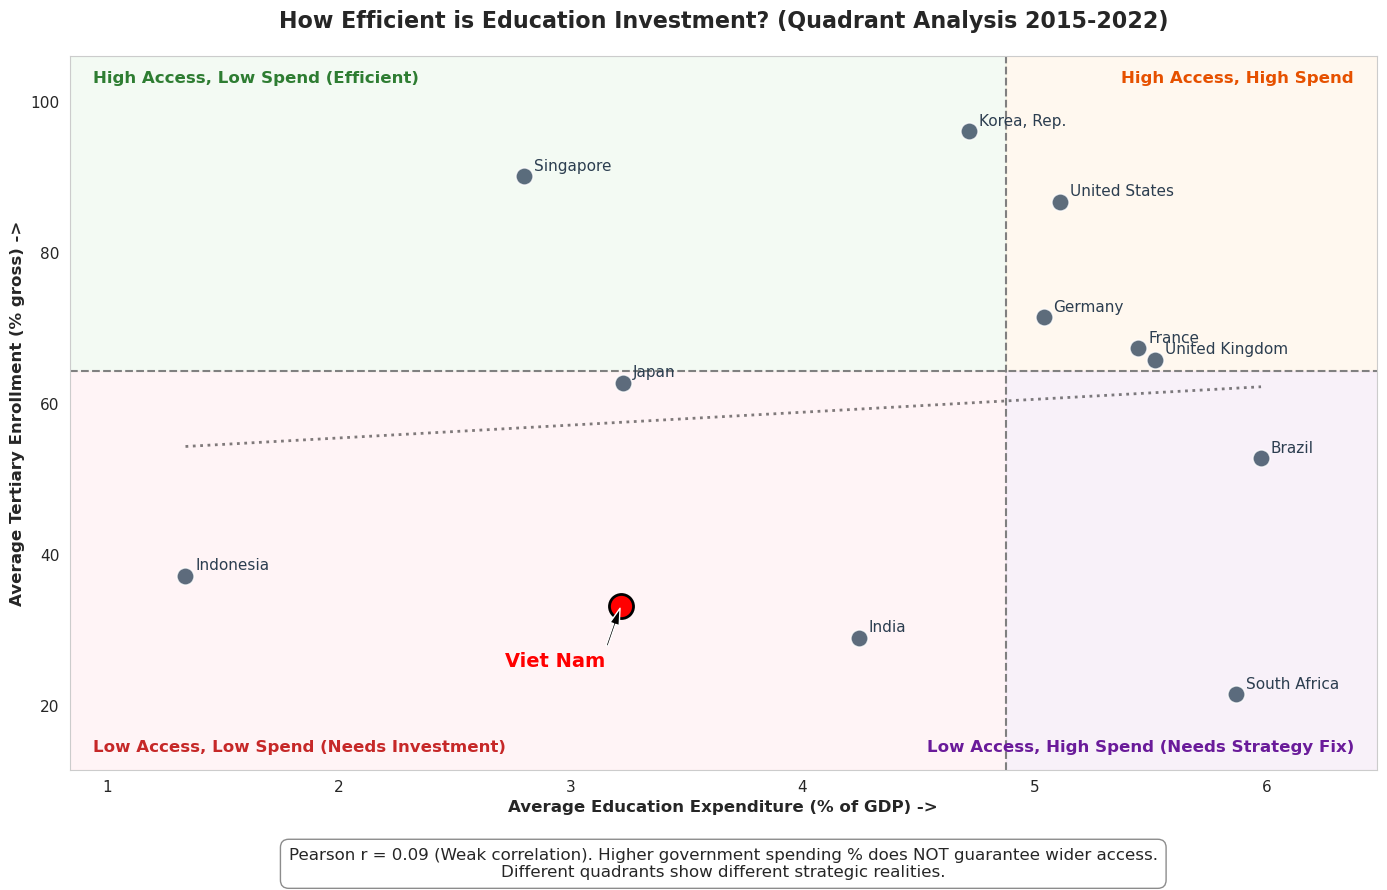


CORRELATION ANALYSIS RESULTS (Full Panel Data)
Pearson correlation r = 0.0911
p-value = 0.3774
Total observations: 96
→ Statistical conclusion: WEAK correlation (|r| < 0.3)


In [10]:
# ====== CHART 4: SCATTER PLOT & QUADRANT ANALYSIS — Education Investment vs Access ======

# Prepare data: pivot 3 variables per (country, year)
pivot_df = df_clean_edu.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Code',
    values='Value'
).reset_index()
pivot_df.columns.name = None

# Rename columns
pivot_df = pivot_df.rename(columns={
    'SE.XPD.TOTL.GD.ZS': 'Edu_Expenditure',
    'SE.TER.ENRR': 'Tertiary_Enrollment',
    'NY.GDP.PCAP.CD': 'GDP_per_capita'
})

scatter_df = pivot_df.dropna(subset=['Edu_Expenditure', 'Tertiary_Enrollment', 'GDP_per_capita']).copy()
avg_df = scatter_df.groupby('Country Name')[['Edu_Expenditure', 'Tertiary_Enrollment']].mean().reset_index()

# Compute overall Pearson correlation
r_value, p_value = stats.pearsonr(scatter_df['Edu_Expenditure'], scatter_df['Tertiary_Enrollment'])

# Calculate medians for quadrants
med_x = avg_df['Edu_Expenditure'].median()
med_y = avg_df['Tertiary_Enrollment'].median()

plt.figure(figsize=(14, 9))

# 1. Clean background with quadrant dividing lines
plt.axvline(med_x, color='gray', linestyle='--', linewidth=1.5, zorder=1)
plt.axhline(med_y, color='gray', linestyle='--', linewidth=1.5, zorder=1)

# 2. Add soft background colors for the 4 quadrants to make them instantly obvious
axis_bounds = [avg_df['Edu_Expenditure'].min() - 0.5, avg_df['Edu_Expenditure'].max() + 0.5, 
               avg_df['Tertiary_Enrollment'].min() - 10, avg_df['Tertiary_Enrollment'].max() + 10]

# Top-Left: High Access, Low Spend (Ideal)
plt.axvspan(axis_bounds[0], med_x, ymin=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), ymax=1, 
            color='#e8f6e9', alpha=0.5, zorder=0)
plt.text(axis_bounds[0] + 0.1, axis_bounds[3] - 2, 'High Access, Low Spend (Efficient)', 
         color='#2e7d32', fontsize=12, fontweight='bold', va='top')

# Top-Right: High Access, High Spend
plt.axvspan(med_x, axis_bounds[1], ymin=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), ymax=1, 
            color='#fff3e0', alpha=0.5, zorder=0)
plt.text(axis_bounds[1] - 0.1, axis_bounds[3] - 2, 'High Access, High Spend', 
         color='#e65100', fontsize=12, fontweight='bold', ha='right', va='top')

# Bottom-Left: Low Access, Low Spend
plt.axvspan(axis_bounds[0], med_x, ymin=0, ymax=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), 
            color='#ffebee', alpha=0.5, zorder=0)
plt.text(axis_bounds[0] + 0.1, axis_bounds[2] + 2, 'Low Access, Low Spend (Needs Investment)', 
         color='#c62828', fontsize=12, fontweight='bold', va='bottom')

# Bottom-Right: Low Access, High Spend
plt.axvspan(med_x, axis_bounds[1], ymin=0, ymax=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), 
            color='#f3e5f5', alpha=0.5, zorder=0)
plt.text(axis_bounds[1] - 0.1, axis_bounds[2] + 2, 'Low Access, High Spend (Needs Strategy Fix)', 
         color='#6a1b9a', fontsize=12, fontweight='bold', ha='right', va='bottom')


# 3. Plot simple regression line to show lack of general correlation
sns.regplot(
    data=avg_df, x='Edu_Expenditure', y='Tertiary_Enrollment',
    scatter=False, color='black', ci=None, line_kws={'linestyle': ':', 'alpha': 0.5, 'linewidth': 2}
)

# 4. Scatter points with clear labels
for i, row in avg_df.iterrows():
    country = row['Country Name']
    x = row['Edu_Expenditure']
    y = row['Tertiary_Enrollment']
    
    # Highlight Viet Nam specifically
    if country == 'Viet Nam':
        plt.scatter(x, y, s=300, color='red', edgecolor='black', linewidth=2, zorder=5)
        # Add an arrow pointing exactly to Vietnam
        plt.annotate('Viet Nam', (x, y), xytext=(x - 0.5, y - 8),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                     fontsize=14, fontweight='bold', color='red', zorder=6)
    else:
        plt.scatter(x, y, s=150, color='#34495e', edgecolor='white', alpha=0.8, zorder=4)
        plt.annotate(country, (x, y), xytext=(7, 4), textcoords='offset points', 
                     fontsize=11, color='#2c3e50', zorder=5)

# 5. Conclusion text box
plt.text(0.5, -0.15,
        f'Pearson r = {r_value:.2f} (Weak correlation). Higher government spending % does NOT guarantee wider access.\nDifferent quadrants show different strategic realities.',
        transform=plt.gca().transAxes, fontsize=12, ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9), zorder=10)

plt.title('How Efficient is Education Investment? (Quadrant Analysis 2015-2022)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Education Expenditure (% of GDP) ->', fontsize=12, fontweight='bold')
plt.ylabel('Average Tertiary Enrollment (% gross) ->', fontsize=12, fontweight='bold')

plt.xlim(axis_bounds[0], axis_bounds[1])
plt.ylim(axis_bounds[2], axis_bounds[3])

plt.grid(False) # Turn off grid to let the quadrant colors show cleanly
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"CORRELATION ANALYSIS RESULTS (Full Panel Data)")
print(f"{'='*60}")
print(f"Pearson correlation r = {r_value:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"Total observations: {len(scatter_df)}")
if abs(r_value) < 0.3:
    print(f"→ Statistical conclusion: WEAK correlation (|r| < 0.3)")
elif abs(r_value) < 0.5:
    print(f"→ Statistical conclusion: MEDIUM correlation (0.3 ≤ |r| < 0.5)")
elif abs(r_value) < 0.7:
    print(f"→ Statistical conclusion: FAIR correlation (0.5 ≤ |r| < 0.7)")
else:
    print(f"→ Statistical conclusion: STRONG correlation (|r| ≥ 0.7)")

#### Analysis, conclusion

**A. Regarding the overall correlation (Trendline):**
- The dashed trendline is nearly flat and the points are widely, randomly dispersed around it. This visual strongly supports the Pearson r value (r < 0.3), indicating a weak linear relationship. This suggests that **higher relative government spending (% GDP) does not necessarily lead to higher tertiary enrollment rates.**

**B. Important Detailed Analysis:**
- **High Access / Low Spend (Top-Left):** **Singapore, Korea, Rep.**
  These systems sit efficiently in the top corner, achieving near-universal tertiary coverage (>90%) with relatively low public expenditure (% GDP). The hidden context here may reflect the role of private sector participation and differences in enormous absolute GDP numbers, effectively reducing the necessary percentage burden strictly from the public state budget.
- **Low Access / High Spend (Bottom-Right):** **South Africa, Brazil**
  Despite designating the largest relative slices of their economic pie to public education (>5.5%), their tertiary enrollment remains relatively low, compared to other countries in the dataset. Their specific coordinates strongly suggest structural inequities or a prioritized need to pump resources heavily into basic literacy and secondary education structurally prior to scaling universities.

**C. Viet Nam’s future strategies:**
- Vietnam is located in the **Low Access / Low Spend** quadrant.  
- This indicates that both tertiary access and public investment levels remain below the group average.  
- To improve tertiary participation, Vietnam may need to gradually increase public investment while also encouraging private sector involvement.

---

### Objective 4: Track trends and measure the growth rate of tertiary education enrollment over time (2013-2022) of a country in each region.

#### Metrics
| Field | Meaning | Rationale |
|---|---|---|
| `SE.TER.ENRR` |  - This indicator measures the gross enrollment ratio for tertiary education (% gross), i.e., [Number of students enrolled in tertiary education regardless of age] / [Population of official tertiary school-age] x 100. | Access to higher education  |

- Reason for choosing metrics: growth rate of tertiary education indicates economy employment rates, analyzing its trends in past years help understand progress in education, employment.

#### Preprocessing 

More helping metrics calculated from Metrics

| Field | Meaning | Rationale |
|---|---|---|
| `abs_change` | Absolute difference between two consecutive years. Calculation method: SE.TER.ENRR in year t - SE.TER.ENRR in year t-1. | Absolute growth/decline rate per year |
| `Region` | Which region (Africa, South Asia, ...) country is in | Group countries by region to show each region trend |


#### Charts
**Line chart over time, colored by region**: 
- Reason for choosing: Suitable for tracking long-term trends and comparing between regions.

**Bar chart for period growth rate**: 
- Reason for choosing: Suitable for direct comparison of fast/slow growing regions within the same metric.


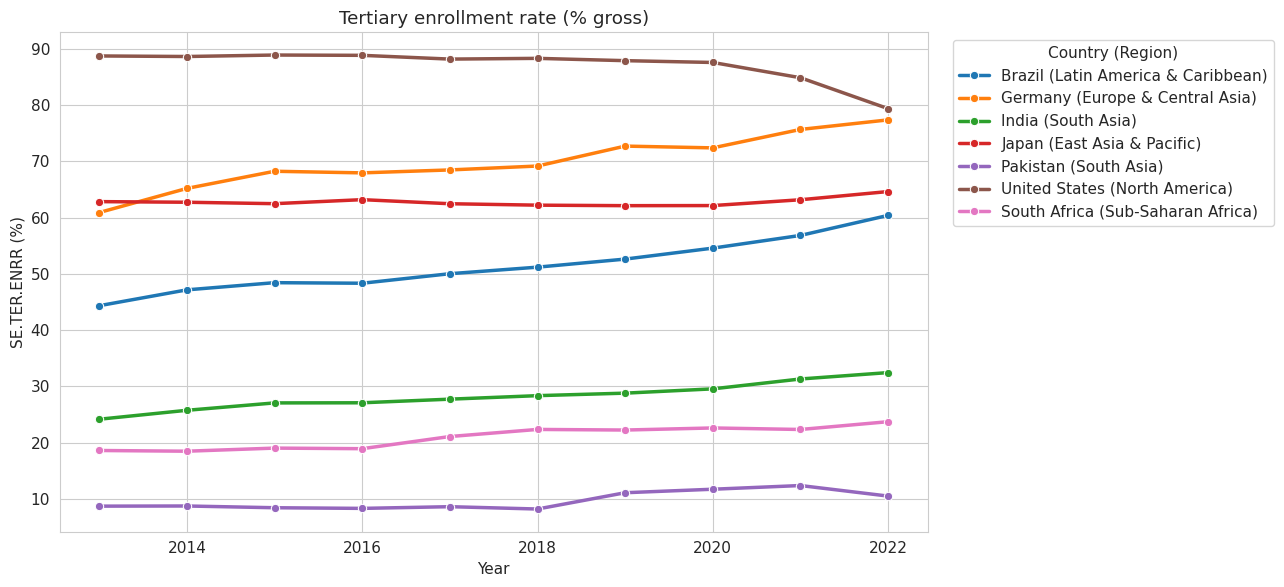

/tmp/ipykernel_66087/3276337014.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_country, x='Label', y='abs_change', palette='viridis')


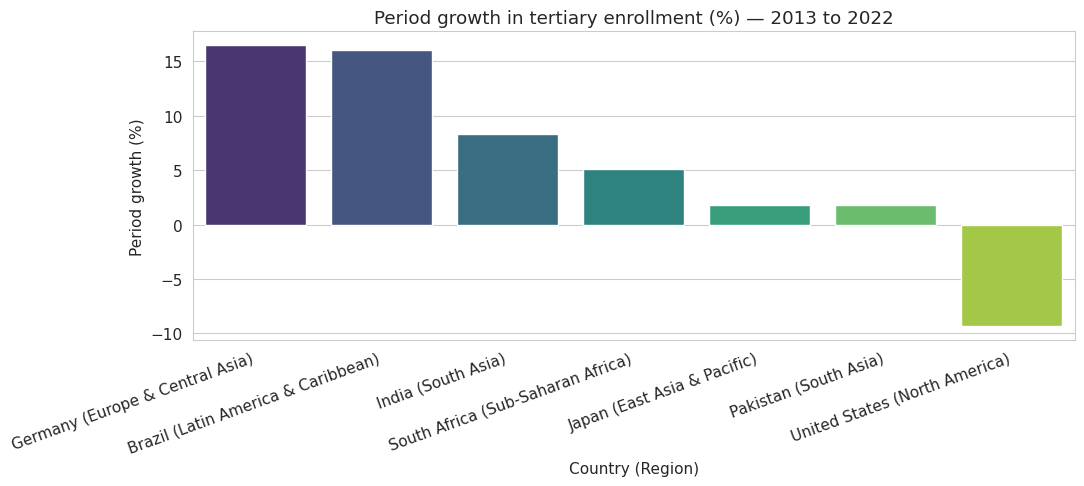

In [11]:
# --- Step 1: Parse all year columns to float first ---
df_clean = df.copy().reset_index(drop=True)
year_cols = [c for c in df_clean.columns if c.startswith('20')]

# Convert '..' and garbage strings -> NaN, cast to float
for col in year_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

ter_long.head()

# Manual Region mapping and representative countries, only use these countries
region_map = {
    'VNM': 'East Asia & Pacific',
    'THA': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific',
    'PHL': 'East Asia & Pacific',
    'IND': 'South Asia',
    'BGD': 'South Asia',
    'PAK': 'South Asia',
    'CHN': 'East Asia & Pacific',
    'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific',
    'DEU': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia',
    'GBR': 'Europe & Central Asia',
    'SWE': 'Europe & Central Asia',
    'USA': 'North America',
    'CAN': 'North America',
    'BRA': 'Latin America & Caribbean',
    'MEX': 'Latin America & Caribbean',
    'ZAF': 'Sub-Saharan Africa',
    'NGA': 'Sub-Saharan Africa',
}
region_df = pd.DataFrame(list(region_map.items()), columns=['Country Code', 'Region'])

# 1 representative country per region
REPRESENTATIVE = {
    'North America':     'USA',
    'Europe & Central Asia': 'DEU',
    'East Asia & Pacific': 'JPN',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Middle East, North Africa, Afghanistan & Pakistan': 'PAK',
    'Sub-Saharan Africa': 'ZAF',
}

# Developing representative countries (1 per developing region)
DEV_REPRESENTATIVE = {
    'East Asia & Pacific': 'VNM',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Sub-Saharan Africa': 'ZAF',
}

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

ter_long.head()

# Filter to representative countries (1 per region)
rep_codes = list(REPRESENTATIVE.values())
rep_df = region_df[region_df['Country Code'].isin(rep_codes)].copy()

# Merge region info to ter_long
ter_rep = ter_long[ter_long['Country Code'].isin(rep_codes)].copy()
# Aggregate by Country-Year and calculate annual rate
country_year = (
    ter_rep.dropna(subset=['Value'])
    .groupby(['Country Code', 'Country Name', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Country Code', 'Country Name', 'Year'])
)
country_year = country_year[(country_year['Year'] >= 2013) & (country_year['Year'] <= 2022)]

country_year['delta_abs'] = country_year.groupby('Country Name')['Value'].diff()
country_year['pct_change'] = country_year.groupby('Country Name')['Value'].pct_change() * 100


# Merge region info for labels
country_year = country_year.merge(
    region_df, left_on='Country Code', right_on='Country Code', how='left'
)
# Build label: "Country (Region)"
country_year['Label'] = country_year['Country Name'] + ' (' + country_year['Region'] + ')'
# print(country_year.head())

# Plot 1: Tertiary enrollment trends by representative country
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', n_colors=len(country_year['Label'].unique()))
sns.lineplot(
    data=country_year,
    x='Year', y='Value',
    hue='Label',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5,
    ax=ax
)
ax.set_title('Tertiary enrollment rate (% gross)')
ax.set_xlabel('Year')
ax.set_ylabel('SE.TER.ENRR (%)')
ax.legend(title='Country (Region)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Compare growth intensity by representative country (start -> end)
start_year = country_year['Year'].min()
end_year = country_year['Year'].max()

start_vals = (
    country_year[country_year['Year'] == start_year][['Label', 'Value']]
    .rename(columns={'Value': 'value_start'})
)
end_vals = (
    country_year[country_year['Year'] == end_year][['Label', 'Value']]
    .rename(columns={'Value': 'value_end'})
)

growth_country = start_vals.merge(end_vals, on='Label', how='inner')
growth_country['abs_change'] = growth_country['value_end'] - growth_country['value_start']
growth_country = growth_country.sort_values('abs_change', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=growth_country, x='Label', y='abs_change', palette='viridis')
plt.title(f'Period growth in tertiary enrollment (%) — {start_year} to {end_year}')
plt.xlabel('Country (Region)')
plt.ylabel('Period growth (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

#### Conclusion

- All countries show an increase in the `SE.TER.ENRR` indicator over the specified period, less variance in growth rates.
- Trend chart shows that  Germany is as high as US, Brazil catching up with Japan, and South Asia countries (India, Pakistan) and South Africa are lowest 
- Germany and Brazil grows largest in this period 2013 - 2022, follow by India
- Surprisingly, Germany, a Europe country grow as much as other developing countries.
- Insight: Tertiary education in South Asia, Africa are the least, the cause may be gender inequality



---

### Objective 5: Analyze the correlation between tertiary enrollment and unemployment rates in developing countries

Analyze the linear correlation between tertiary enrollment) and total unemployment rate in developing countries from 2000 - 2024. We are interested in education and employment across regions, see if it's true that more "knowledge" means more work.

#### Metrics

| Field | Meaning | Rationale |
|---|---|---|
| `SE.TER.ENRR` | Total tertiary enrollment / official age group population x 100. **Calculation method:** Total tertiary enrollment / official tertiary school-age population x 100. | Access to higher education  |
| `SL.UEM.TOTL.ZS` | Percentage of labor force without work but seeking employment (modeled ILO).  **Calculation method:** (Number of unemployed persons) / (Total labor force) x 100. | Labor market pressure  |

**Rationale for these metrics:** Both reflect two aspects of human resource development - education, work (employment opportunities). Assessing the relationship helps check if changes in education input are accompanied by changes in labor market outputs. 


#### Charts

**Chart 1 - Scatter plot:**
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** assists in evaluating the stability of the observed linear trend.
    - Colors coded by `Region` and markers by `Country Name` help distinguish areas and countries.

**Chart 2 - Lollipop chart:**
- **Rationale:** Lollipop chart plots Pearson r for each region. Comparing to bar chart, it can plot more values, easier to see for "high" values.

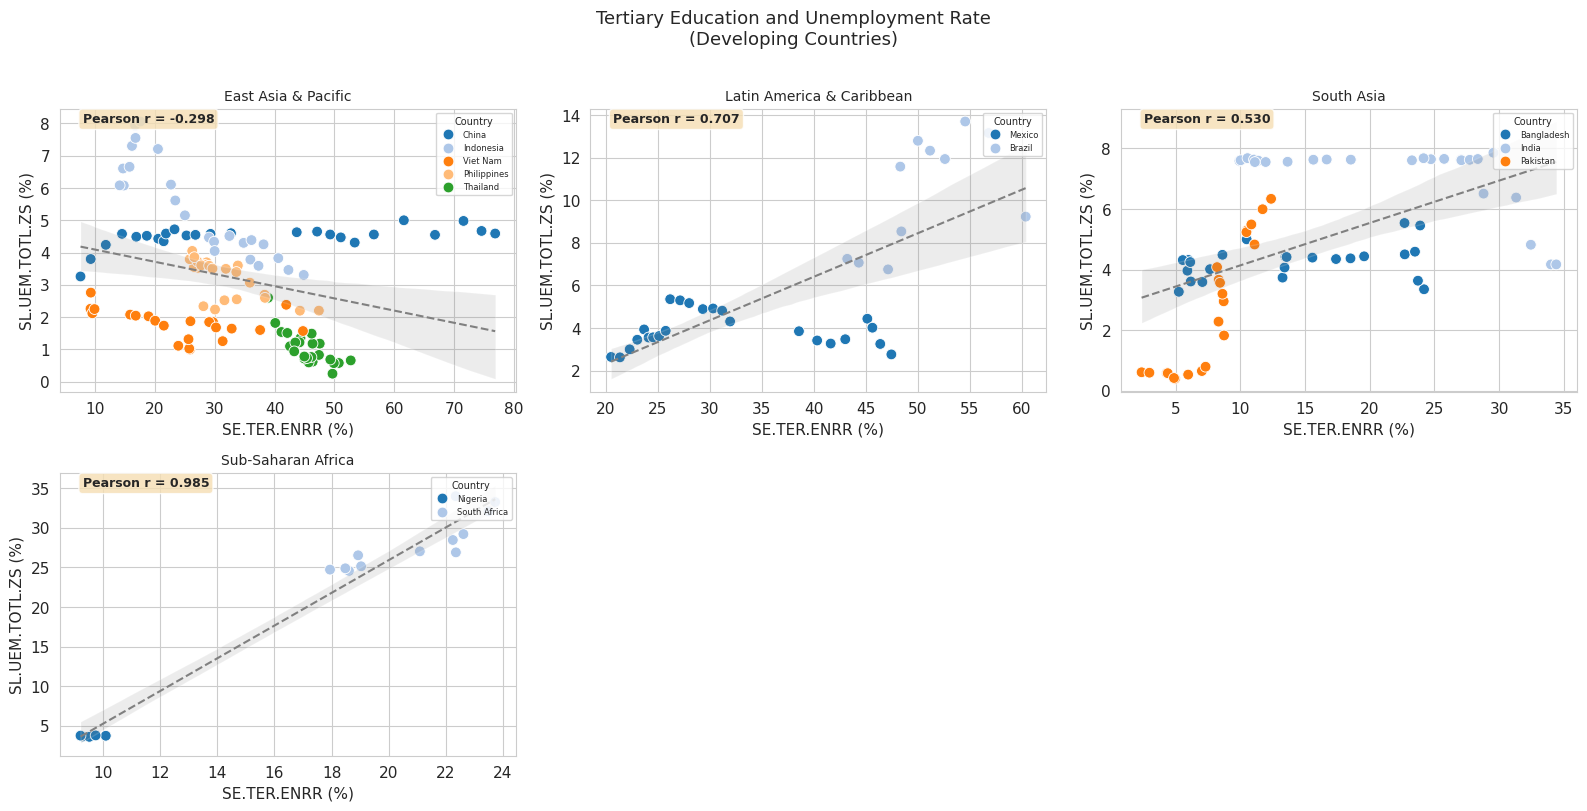

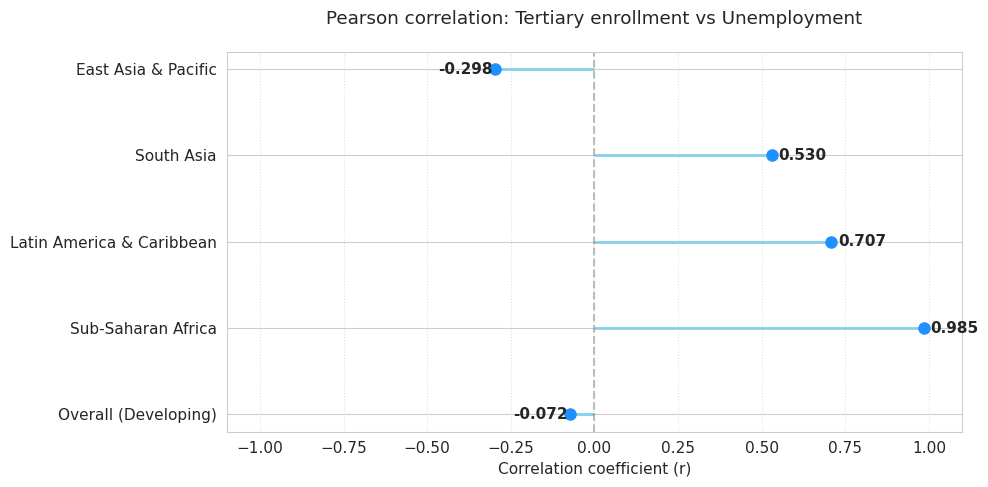

In [12]:
DEV_CODES = ['VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'BRA', 'MEX', 'ZAF', 'NGA']

# Wide tables for both indicators
ter_row = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()
unemp_row = df_clean[df_clean['Series Code'] == 'SL.UEM.TOTL.ZS'].copy()

def rename_year_cols(sub_df, val_name):
    sub = sub_df[['Country Name', 'Country Code'] + year_cols].copy()
    sub = sub.rename(columns={c: f'{c}_{val_name}' for c in year_cols})
    return sub

ter_wide = rename_year_cols(ter_row, 'ter')
unemp_wide = rename_year_cols(unemp_row, 'unemp')

corr_df = ter_wide.merge(unemp_wide, on=['Country Name', 'Country Code'])
corr_df = corr_df.merge(region_df, on='Country Code', how='left')

# Melt to long
ter_long2 = ter_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in ter_wide.columns if c.endswith('_ter')],
    var_name='YearRaw', value_name='TerValue'
)
unemp_long2 = unemp_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in unemp_wide.columns if c.endswith('_unemp')],
    var_name='YearRaw', value_name='UnempValue'
)

ter_long2['Year'] = ter_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)
unemp_long2['Year'] = unemp_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)

corr_long = ter_long2.merge(
    unemp_long2[['Country Name', 'Country Code', 'Year', 'UnempValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

corr_long = corr_long.merge(region_df, on='Country Code', how='left')
developing_long = corr_long[corr_long['Country Code'].isin(DEV_CODES)].copy()

# print(f"Developing countries: {developing_long['Country Code'].nunique()}")

# Scatter: each region in one subplot, color by country
regions = developing_long['Region'].dropna().unique()
n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions)):
    df_r = developing_long[developing_long['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='UnempValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='UnempValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    r_val = df_r[['TerValue', 'UnempValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.UEM.TOTL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='upper right')

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.suptitle(
    'Tertiary Education and Unemployment Rate\n(Developing Countries)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Pearson correlation
overall_corr = developing_long[['TerValue', 'UnempValue']].corr().iloc[0, 1]
region_corr = (
    developing_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'UnempValue']].corr().iloc[0, 1])
    .reset_index()
    .rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)

# Plotting Lollipop Chart for Correlations
plt.figure(figsize=(10, 5))
plot_data = pd.concat([
    pd.DataFrame({'Region': ['Overall (Developing)'], 'Pearson_r': [overall_corr]}),
    region_corr
]).reset_index(drop=True)

plt.hlines(y=plot_data['Region'], xmin=0, xmax=plot_data['Pearson_r'], color='skyblue', linewidth=2)
plt.plot(plot_data['Pearson_r'], plot_data['Region'], "o", markersize=8, color='dodgerblue')

for i, r in enumerate(plot_data['Pearson_r']):
    plt.text(r + (0.02 if r >= 0 else -0.17), i, f"{r:.3f}", va='center', fontweight='bold')

plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.title('Pearson correlation: Tertiary enrollment vs Unemployment', pad=20)
plt.xlabel('Correlation coefficient (r)')
plt.xlim(-1.1, 1.1)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



#### Conclusion

- Correlation intensity and direction vary significantly between regions even across years, suggesting that the relationship between tertiary enrollment and unemployment is not uniform across the developing world.

**Regions:**
- Tertiary enrollment and Unemployment relationships have large variation across regions 
- Surprisingly
- Surprisingly, **Sub-Saharan Africa** exhibits a nearly perfect positive correlation (r = 0.985).  indicating that increases in tertiary enrollment are closely aligned with increases in unemployment rates in the sampled countries, follow by strong relationships in **Latin America**, **South Asia**.
    - However, in scatterplot **South Asia** shows many points and consistent relationships, hence, the proof of correlation is the strongest. 
        - **Sub-Saharan Africa** also shows they have least points, we need more data for this region to verify.
- **East Asia & Pacific** is the only region showing a negative trend, though the correlation is weak.
- **Latin America & Caribbean** and **South Asia** show moderate to strong positive correlations .


---

### Objective 6: Correlation analysis between Service Sector Employment and Tertiary Enrollment by region

Analyze simultaneously by geographical region (Region) to determine the relationship between economic restructuring and education across different regions from 2000 - 2024.


#### Metrics

| Field | Meaning | Rationanle |
|---|---|---|
| `SL.SRV.EMPL.ZS` | This indicator measures the share of the labor force employed in the services sector. **Calculation method:** (Number of persons employed in services sector) / (Total labor force) x 100. | The degree of economic restructuring toward a service-based economy.|

`SE.TER.ENRR` explained above

**Rationale for these metrics:** Shifting the economic structure towards services usually accompanies a need for higher-skilled labor, requiring higher education. Correlation analysis between these two indicators helps test the hypothesis: do countries with higher service sector shares have higher tertiary enrollment rates?

#### Charts

**Chart 1 - Scatter plot:**
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** supports evaluating the stability of the linear trend.
    - Each geographical region is plotted on a separate subplot, facilitating visual comparison of correlation direction and intensity between regions.

**Chart 2 - Lollipop chart:**
- **Rationale:** Lollipop chart plots Pearson r for each region. Comparing to bar chart, it can plot more values, easier to see for "high" values.

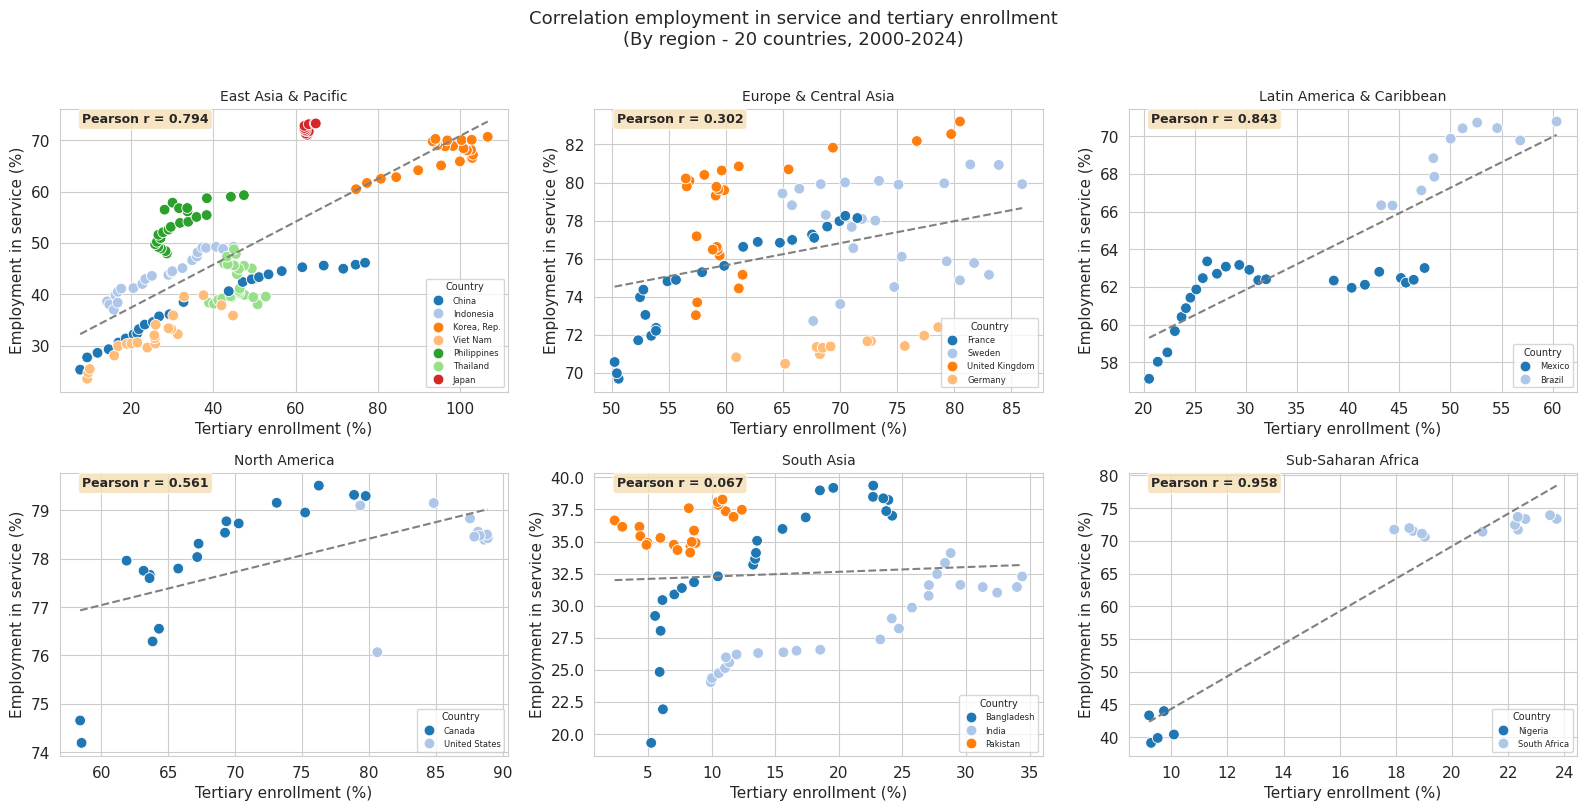

--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---
Overall: r = 0.6890


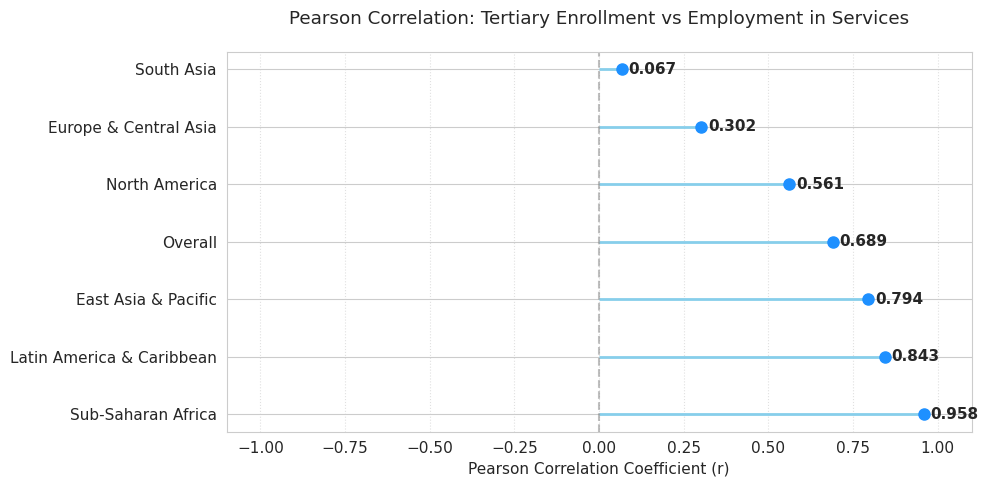

In [13]:
# Data Preparation: SL.SRV.EMPL.ZS vs SE.TER.ENRR
srv_row = df_clean[df_clean['Series Code'] == 'SL.SRV.EMPL.ZS'].copy()
srv_wide = rename_year_cols(srv_row, 'srv')

q3_df = ter_wide.merge(srv_wide, on=['Country Name', 'Country Code'])

# Melt to long format
srv_long = srv_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in srv_wide.columns if c.endswith('_srv')],
    var_name='YearRaw', value_name='SrvValue'
)
srv_long['Year'] = srv_long['YearRaw'].str.extract(r'(\d{4})').astype(int)

q3_long = ter_long2.merge(
    srv_long[['Country Name', 'Country Code', 'Year', 'SrvValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

q3_long = q3_long.merge(region_df, on='Country Code', how='left')

# Chart 1: Scatter plot with subplots per region
regions_q3 = q3_long['Region'].dropna().unique()
n = len(regions_q3)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions_q3)):
    df_r = q3_long[q3_long['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='SrvValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='SrvValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=None
    )
    r_val = df_r[['TerValue', 'SrvValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('Tertiary enrollment (%)')
    ax.set_ylabel('Employment in service (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='lower right')

for ax in axes[len(regions_q3):]:
    ax.set_visible(False)

fig.suptitle(
    'Correlation employment in service and tertiary enrollment\n(By region - 20 countries, 2000-2024)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Pearson coefficient: overall and by region
print('--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---')
overall_r = q3_long[['TerValue', 'SrvValue']].corr().iloc[0, 1]
print(f'Overall: r = {overall_r:.4f}')

region_r = (
    q3_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'SrvValue']].corr().iloc[0, 1])
    .reset_index().rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
# print('By Region:')
# print(region_r.to_string(index=False))

# Lollipop chart: Pearson r by region
plot_data = pd.concat([
    pd.DataFrame({'Region': ['Overall'], 'Pearson_r': [overall_r]}),
    region_r
]).reset_index(drop=True).sort_values('Pearson_r', ascending=False)

plt.figure(figsize=(10, 5))
plt.hlines(y=plot_data['Region'], xmin=0, xmax=plot_data['Pearson_r'], color='skyblue', linewidth=2)
plt.plot(plot_data['Pearson_r'], plot_data['Region'], "o", markersize=8, color='dodgerblue')
for i, r in enumerate(plot_data['Pearson_r']):
    plt.text(r + (0.02 if r >= 0 else -0.07), i, f"{r:.3f}", va='center', fontweight='bold')
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.title('Pearson Correlation: Tertiary Enrollment vs Employment in Services', pad=20)
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.xlim(-1.1, 1.1)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Conclusion

**Overall:**
- Pearson coefficient: **r = 0.689** → |r| ~ 0.7, **strong positive linear correlation**.

**Regional Results:**
Every region show positive result, higher education correlates with increase in service sector labor shares.

Suprisingly, highest region are regions with many developing countries: (Sub-Saharan) Africa, Latin America & Caribbean, East Asia & Pacific.
- However, in scatterplot East Asia & Pacific shows many points and consistent relationships, hence, the proof of correlation is the strongest.

Intensity varies across regions; South Asia have weaker relationships, suggesting that the shift to services is not yet uniform or high-education demand hasn't increased proportionally:
- North America: r = 0.464 (positive, moderate).
- South Asia: r = 0.447 (positive, moderate).
- Europe & Central Asia: r = 0.370 (positive, moderate).

**Insight for Objective 4, 5, 6**: While tertiary education helps increase service sector employment, it does not mean more employment.

---

### Objective 7: The Impact of Health Expenditure on Female Life Expectancy

This section investigates the evolutionary trend over 14 years (2010-2023) to assess how financial investment in healthcare correlates with women's longevity. By observing the time-series data across 11 representative countries, we aim to test the hypothesis that higher health expenditure directly translates into higher female life expectancy. Furthermore, it helps evaluate whether the efficiency of this spending differs between developed and developing nations.

#### Metrics
* **`SH.XPD.CHEX.PC.CD` — Current health expenditure per capita :** This indicator measures the actual financial investment a country commits to its healthcare system per person.
* **`SP.DYN.LE00.FE.IN` — Life expectancy at birth, female:** This indicator reflects the overall health status and expected longevity of women.

#### Charts
**Chart Type:** Small Multiples (Grid) of Dual-Axis Charts comparing Female Tertiary Education Enrollment (solid blue line with filled area, left axis) and Adolescent Fertility Rate (dashed red line, right axis) across 6 representative countries from 2000 to 2024.

* **Reason for choosing this chart:** To analyze the longitudinal relationship between women's higher education and early motherhood, our group utilized a **Small Multiples Dual-Axis Chart** design. Because the two variables operate on completely different numerical scales (percentages vs. births per 1,000 women), employing dual Y-axes is mathematically essential for an accurate, side-by-side visual comparison. The line and area combination effectively tracks the historical trajectories over the 25-year span. Most importantly, separating the data into individual country subplots (a grid) eliminates visual clutter, allowing the audience to clearly and independently observe the strong inverse correlation (the "scissor effect") within each nation's unique socio-economic context.

In [14]:
df_fert_raw = df_raw.copy()

INDICATORS = {
    'SE.TER.ENRR.FE': 'Tertiary_Edu',
    'SP.ADO.TFRT': 'Adolescent_Fertility'
}

pivot_q3 = df_fert_raw[df_fert_raw['Series Code'].isin(INDICATORS.keys())].copy()
year_cols_q3 = [c for c in pivot_q3.columns if c.startswith('20') and c.endswith(']')]

pivot_q3 = pivot_q3.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols_q3, var_name='YearRaw', value_name='Value'
)
pivot_q3['Year'] = pivot_q3['YearRaw'].str.extract(r'(\d{4})').astype(int)
pivot_q3['Value'] = pd.to_numeric(pivot_q3['Value'], errors='coerce')
pivot_q3 = pivot_q3.drop_duplicates(subset=['Country Name', 'Series Code', 'Year'])
pivot_q3['Value'] = pivot_q3.groupby(['Country Name', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

pivot_q3 = pivot_q3.pivot_table(
    index=['Country Name', 'Year'], columns='Series Code', values='Value', aggfunc='mean'
).reset_index()
pivot_q3.rename(columns=INDICATORS, inplace=True)
pivot_q3 = pivot_q3.dropna(subset=['Tertiary_Edu', 'Adolescent_Fertility'])

countries = pivot_q3['Country Name'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Female Tertiary Education vs. Adolescent Fertility (2000-2024)', fontsize=18, fontweight='bold', y=1.05)
axes = axes.flatten()

color_edu = '#3182bd'  # Blue for Education
color_fert = '#de2d26'  # Red for Fertility

for i, country in enumerate(countries):
    ax1 = axes[i]
    cdata = pivot_q3[pivot_q3['Country Name'] == country].sort_values('Year')
    ax1.fill_between(cdata['Year'], cdata['Tertiary_Edu'], color=color_edu, alpha=0.2)
    line1, = ax1.plot(cdata['Year'], cdata['Tertiary_Edu'], color=color_edu, linewidth=2.5, label='Tertiary Enrollment (%)')
    ax1.set_title(country, fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Female Tertiary Enrollment (% Gross)', color=color_edu, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_edu)
    ax1.set_ylim(0, max(120, cdata['Tertiary_Edu'].max() + 10))
    ax1.set_xlim(2000, 2024)
    ax1.set_xticks([2000, 2006, 2012, 2018, 2024])

    ax2 = ax1.twinx()
    line2, = ax2.plot(cdata['Year'], cdata['Adolescent_Fertility'], color=color_fert, linewidth=3, linestyle='--', label='Adolescent Fertility Rate')
    ax2.set_ylabel('Adolescent Fertility Rate', color=color_fert, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_fert)
    ax2.set_ylim(0, max(140, cdata['Adolescent_Fertility'].max() + 20))

    if i == 0:
        ax1.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


KeyError: ['Tertiary_Edu', 'Adolescent_Fertility']

#### Conclusion

**Chart 1: Observations & Conclusions over the 25-Year Trend:**

Analyzing the 6-country grid from 2000 to 2024 reveals three distinct demographic-educational profiles:

* **1. The "Fully Shielded" Developed Nations :** In these countries, female tertiary enrollment has been saturated at very high levels . Consequently, their adolescent fertility rates  are completely flattened near the bottom . The "educational shield" here is fully active and perfectly stable over decades.
* **2. The Active Transition :** The United States showcases a beautiful active decline: while education remains fully saturated , its teen pregnancy rate steadily plunges from ~40 down to ~15. Viet Nam presents the most dynamic "X-shaped" volatility. Its female tertiary education experienced a massive, albeit fluctuating, surge , which is actively fighting to push the adolescent fertility rate back down after a cultural spike in the mid-2010s.
* **3. The Developing Challenge :** These nations highlight the danger zone. Rwanda shows a slow but commendable climb in female university enrollment , which mirrors a steady decline in early pregnancies . Nigeria, on the other hand, illustrates the starkest contrast: stagnated tertiary enrollment  correlates directly with astronomical adolescent fertility rates . 
* **Data Note:** *The visible gaps in the trendlines for Nigeria , Japan , and the US are due to standard missing reporting years in the World Bank database. However, they do not invalidate the overarching macro-trend.*
* **Final Conclusion:** The time-series data undeniably confirms the hypothesis. Expanding access to higher education for females is not a short-term fix, but a long-term prerequisite for eradicating early pregnancies and unlocking female human capital globally.

---
## Objective 8: Analyze the relationship between health expenditure and female life expectancy


### Analysis Objectives

To examine the **relationship between health expenditure and female life expectancy** across 8 countries, by analyzing both the **cross-sectional correlation** and the **within-country temporal trends** over time.  

This objective aims to evaluate whether higher health spending leads to better health outcomes, and to identify differences in **efficiencys and plateau effect** across countries at different development levels.  

The analysis is based on the variables `SH.XPD.CHEX.PC.CD` and `SP.DYN.LE00.FE.IN`, using **data from 8 countries** over the period **2010–2023**.  


### Analysis Objectives

To measure and analyze the degree of **relationship between health expenditure and female life expectancy** across **8 countries** over the period **2010–2023**, using both **cross-sectional** and **within-country** perspectives.  

Our group selected this period because it provides a **recent and continuous time span** with sufficient data points to capture both **long-term trends** and **short-term shocks** (e.g., COVID-19 impacts).  

This objective is set to test the hypothesis:  
*“Do countries with higher health expenditure per capita tend to achieve higher female life expectancy, and does this relationship differ across development levels?”*  

The analysis is based on the variables `SH.XPD.CHEX.PC.CD` and `SP.DYN.LE00.FE.IN`, using **data from 8 countries** over the period **2010–2023**. 

### Metrics

`SH.XPD.CHEX.PC.CD` – **Current health expenditure per capita (USD)**: Measures the actual financial investment a country commits to its healthcare system per person.  

`SP.DYN.LE00.FE.IN` – **Female life expectancy at birth (years)**: Measures the average number of years a newborn female is expected to live.  

### Reason for selecting metrics

These two variables are selected because they represent the **input–output relationship** in healthcare systems:  
- Health expenditure captures **resource allocation (input)**  
- Life expectancy captures **health outcomes (output)**  

Analyzing them together allows assessment of not only **correlation**, but also **efficiency and effectiveness** of healthcare systems across countries.  

### Chart 1: Scatter Plot + Regression — Health Expenditure vs Female Life Expectancy

- **Reason for choosing a Scatter Plot with Regression Line:**
  - This is a standard **statistical visualization** for analyzing the relationship between two continuous variables.  
  - It allows:
    - **Identifying correlation** between health expenditure and life expectancy  
    - **Detecting outliers** (e.g., high spending but relatively low outcomes)  
    - **Observing clustering patterns** among countries with similar development levels  
  - The addition of a **regression line** provides a clear summary of the **overall trend**, while the **Pearson correlation coefficient (r)** quantifies the strength of the relationship.  

### Chart 2: Dual-Axis Line Charts — Health Expenditure & Female Life Expectancy by Country (Grouped by Development Level)

- **Reason for choosing Dual-Axis Line Charts:**
  - This visualization is ideal for analyzing **time-series relationships within each country**, while simultaneously comparing **two related variables**:
    - **Health expenditure (input)**  
    - **Female life expectancy (output)**  

- **Reason for grouping countries (Developed vs Developing):**
  - Dividing countries into **developed** and **developing groups** allows clearer comparison of **structural differences** in how health expenditure translates into health outcomes.  

- **Analytical advantages:**
  - Enables tracking whether **increases in spending correspond to improvements in life expectancy** within each country  
  - Allows **clear comparison within the same development level**.

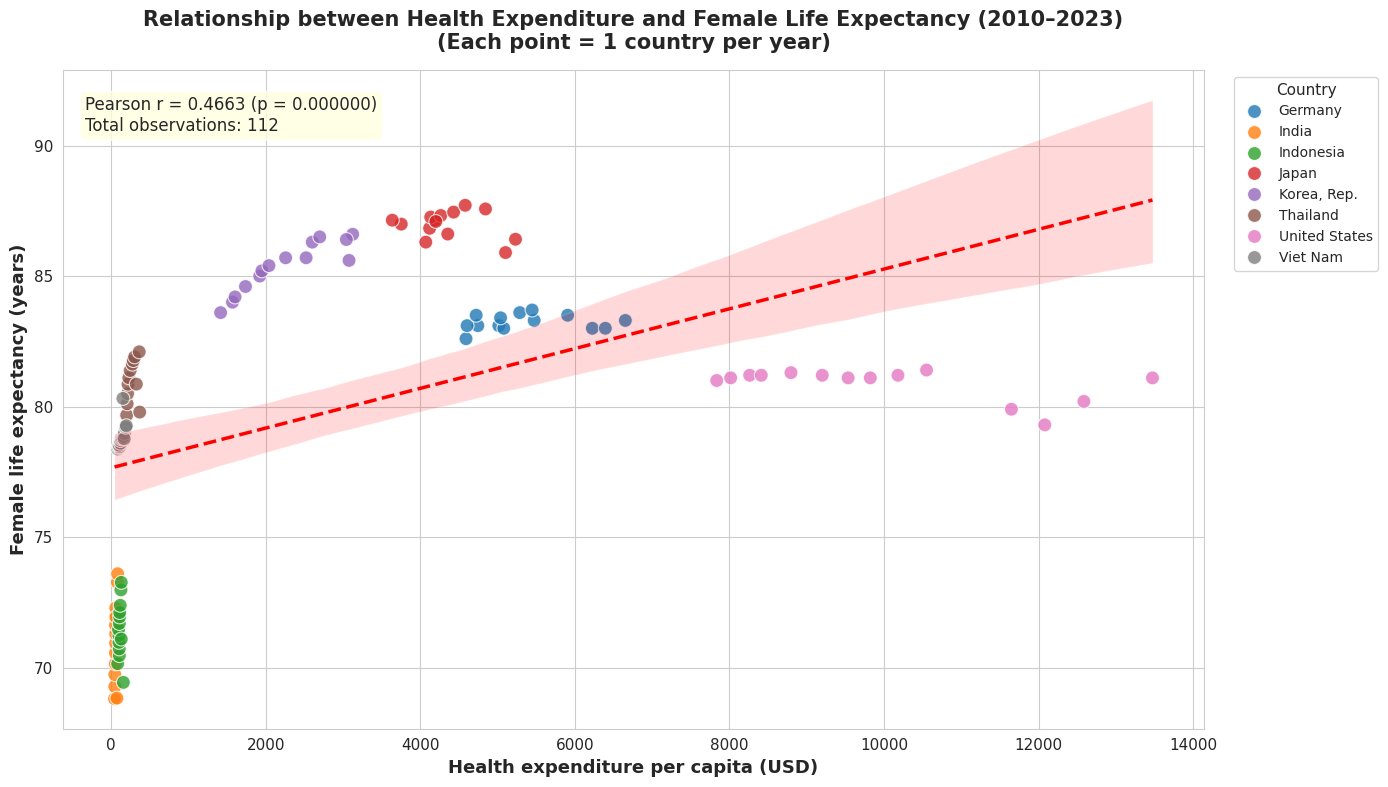

Total observations: 112
→ Moderate correlation (0.3 ≤ |r| < 0.5)


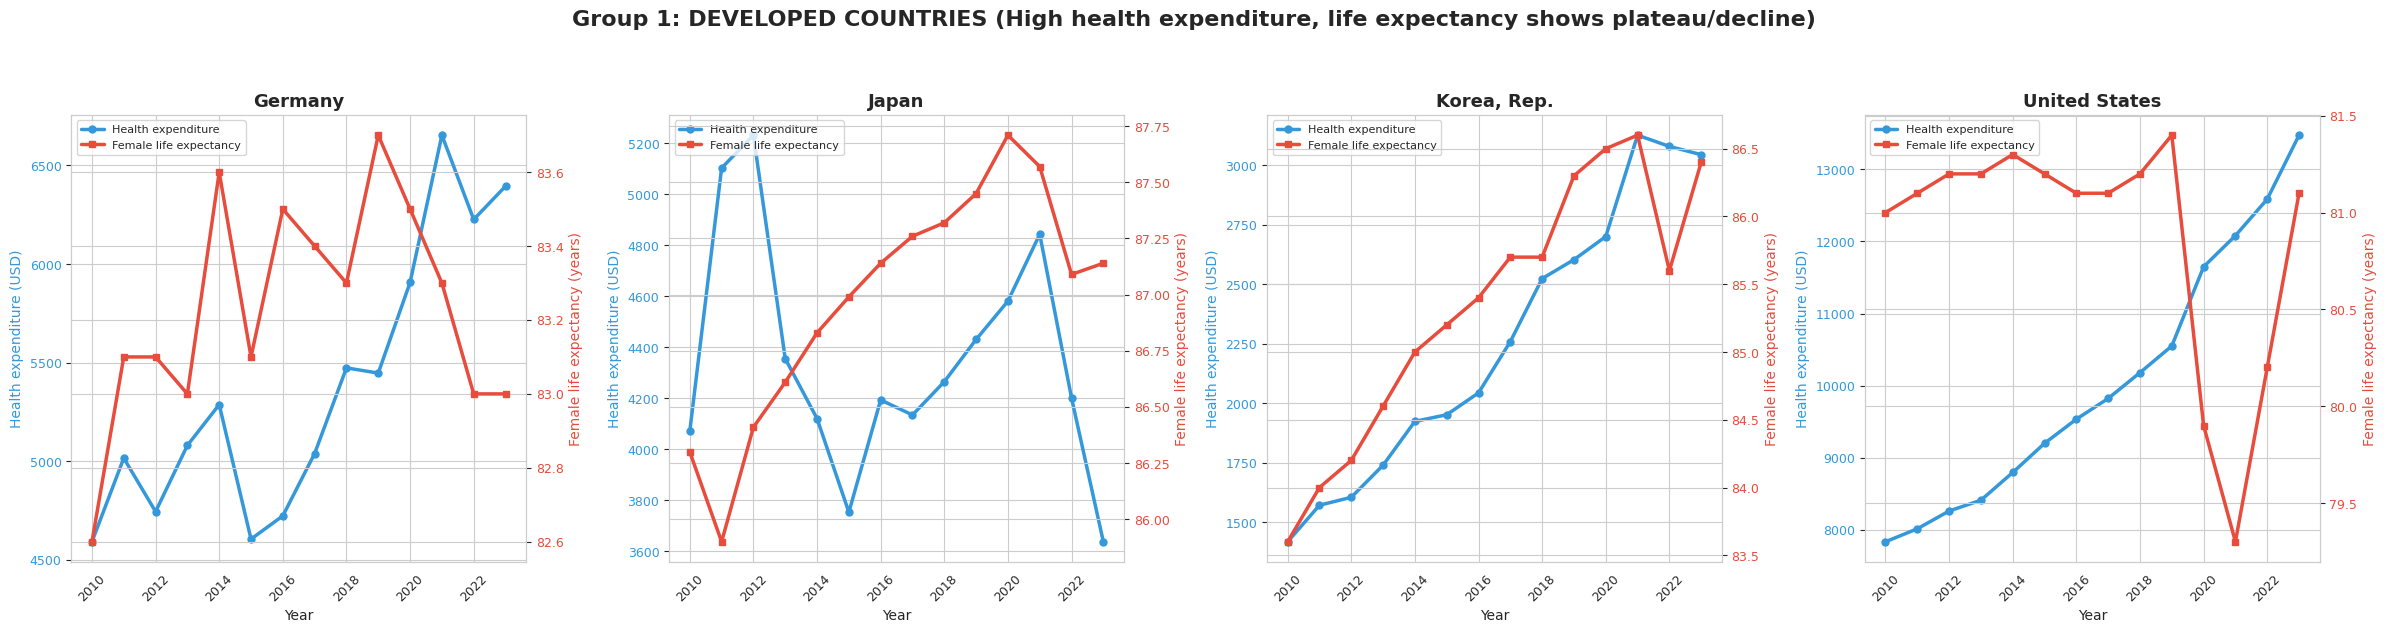

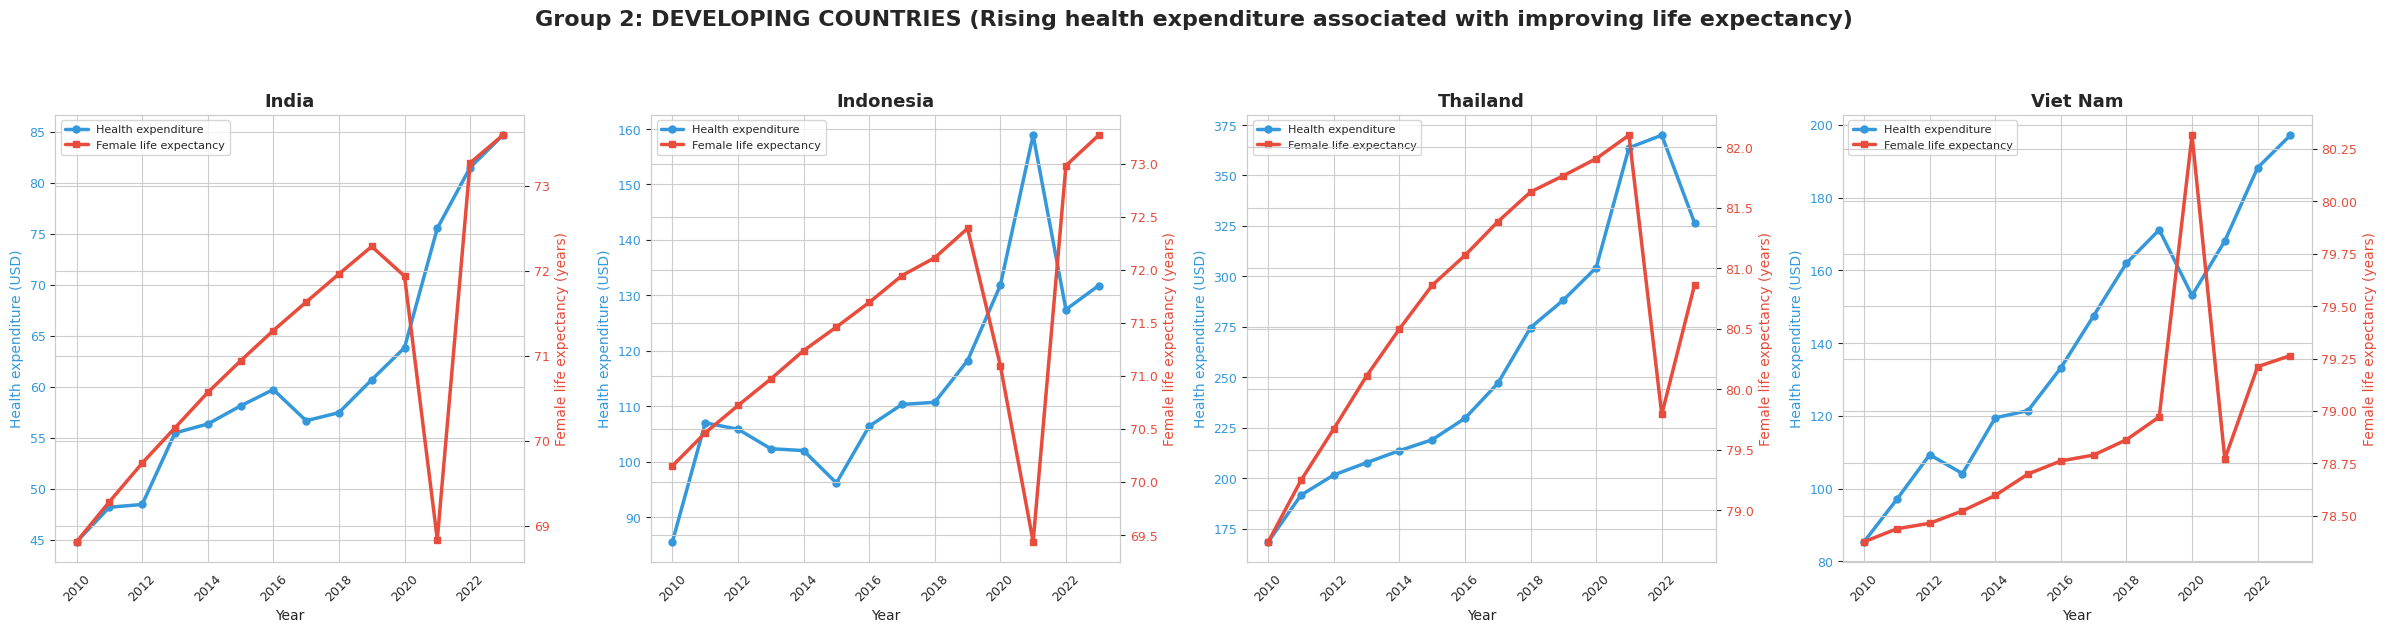

In [ ]:
# ====== CHART 2: SCATTER PLOT + REGRESSION — Health Expenditure vs Female Life Expectancy ======

# Prepare data: pivot variables
pivot_df = df_clean.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Code',
    values='Value'
).reset_index()
pivot_df.columns.name = None

# Rename columns for readability
pivot_df = pivot_df.rename(columns={
    'SH.XPD.CHEX.PC.CD': 'health_exp',
    'SP.DYN.LE00.FE.IN': 'life_exp_female',
    'SP.POP.TOTL.FE.ZS': 'female_pop'
})  


scatter_df = pivot_df.dropna(subset=['health_exp', 'life_exp_female']).copy()

# Compute Pearson correlation
r_value, p_value = stats.pearsonr(scatter_df['health_exp'], scatter_df['life_exp_female'])

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot colored by country
palette = sns.color_palette('tab10', n_colors=len(scatter_df['Country Name'].unique()))
sns.scatterplot(data=scatter_df, x='health_exp', y='life_exp_female',
                hue='Country Name', palette=palette, s=100, alpha=0.8, edgecolor='white', ax=ax)

# Overall regression line
sns.regplot(data=scatter_df, x='health_exp', y='life_exp_female',
            scatter=False, color='red', line_kws={'linewidth': 2.5, 'linestyle': '--'}, ax=ax)

# Statistical annotation
ax.text(0.02, 0.96,
        f'Pearson r = {r_value:.4f} (p = {p_value:.6f})\n'
        f'Total observations: {len(scatter_df)}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.title('Relationship between Health Expenditure and Female Life Expectancy (2010–2023)\n(Each point = 1 country per year)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Health expenditure per capita (USD)', fontsize=13, fontweight='bold')
plt.ylabel('Female life expectancy (years)', fontsize=13, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Total observations: {len(scatter_df)}")
if abs(r_value) < 0.3:
    print("→ Weak correlation (|r| < 0.3)")
elif abs(r_value) < 0.5:
    print("→ Moderate correlation (0.3 ≤ |r| < 0.5)")
elif abs(r_value) < 0.7:
    print("→ Fair correlation (0.5 ≤ |r| < 0.7)")
else:
    print("→ Strong correlation (|r| ≥ 0.7)")

# ====== CHART 2: LINE CHART — Health Expenditure & Female Life Expectancy by Country ======

# Get list of countries and split into groups
actual_countries = scatter_df['Country Name'].unique()
dev_countries = sorted([c for c in actual_countries if any(d in c for d in ['Germany', 'Japan', 'Korea', 'United States'])])
devg_countries = sorted([c for c in actual_countries if any(d in c for d in ['India', 'Indonesia', 'Thailand', 'Viet Nam'])])

def plot_country(ax, country):
    country_data = scatter_df[scatter_df['Country Name'] == country].sort_values('Year')
    
    # Left axis: Health expenditure
    color1 = '#3498db'
    ax.plot(country_data['Year'], country_data['health_exp'], 
             color=color1, marker='o', linewidth=2.5, markersize=5, label='Health expenditure')
    ax.set_ylabel('Health expenditure (USD)', color=color1, fontsize=10)
    ax.tick_params(axis='y', labelcolor=color1, labelsize=9)
    
    # Right axis: Life expectancy
    ax2 = ax.twinx()
    color2 = '#e74c3c'
    ax2.plot(country_data['Year'], country_data['life_exp_female'],
             color=color2, marker='s', linewidth=2.5, markersize=5, label='Female life expectancy')
    ax2.set_ylabel('Female life expectancy (years)', color=color2, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=9)
    
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    
    # Set x-axis ticks every 2 years
    ax.set_xticks(range(2010, 2024, 2))
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    
    # Legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# --- Figure 1: Group 1 ---
fig1, axes1 = plt.subplots(1, 4, figsize=(24, 6))
for idx, country in enumerate(dev_countries):
    plot_country(axes1[idx], country)

fig1.suptitle('Group 1: DEVELOPED COUNTRIES (High health expenditure, life expectancy shows plateau/decline)',
             fontsize=16, fontweight='bold', y=1.05)
fig1.tight_layout()
plt.show()

# --- Figure 2: Group 2 ---
fig2, axes2 = plt.subplots(1, 4, figsize=(24, 6))
for idx, country in enumerate(devg_countries):
    plot_country(axes2[idx], country)

fig2.suptitle('Group 2: DEVELOPING COUNTRIES (Rising health expenditure associated with improving life expectancy)',
             fontsize=16, fontweight='bold', y=1.05)
fig2.tight_layout()
plt.show()

### **Analysis**

#### A. Overall Relationship
Overall, the chart indicates a **moderate positive correlation** between health expenditure and female life expectancy. Countries that spend more on healthcare generally **tend to achieve higher life expectancy for women**.  

However, this relationship is **not strictly linear**, as reflected by the wide dispersion of data points. This suggests that **health expenditure alone cannot fully explain variations in health outcomes** across countries.

#### B. Signs of a Plateau Effect
A clear pattern emerges when comparing different development levels:

- In **low-expenditure countries** (India, Indonesia, Viet Nam, Thailand), female life expectancy **increases rapidly** as spending rises.  
  → This indicates that health expenditure plays a **crucial and highly effective role** during the early stages of development.

- In **high-expenditure countries** (Germany, Japan, Korea, United States), female life expectancy remains **consistently high (~81–88 years)** but shows **minimal improvement despite rising spending**.  
  → This means that in developed countries, a **plateau effect** is a common phenomenon.

#### C. Developed vs Developing Countries

**Developed Countries Group:**
- Countries such as Germany, Japan, and Korea maintain **high life expectancy with stable spending**, suggesting they have reached a **mature stage of healthcare development**.  
- The **United States** stands out as an outlier: despite having the **highest health expenditure per capita**, its female life expectancy (~79–81 years) is **lower than Japan and Korea**.  
  → This highlights that **higher spending does not guarantee better outcomes**, especially when inefficiencies exist within the healthcare system.

**Developing Countries Group:**
- Countries such as India, Indonesia, Thailand, and Viet Nam show a **clear upward trend in life expectancy alongside increased spending**.  
  → This confirms that **health investment is highly impactful at early development stages**.  
- Within this group, **Thailand and Viet Nam show higher female life expectancy alongside relatively higher health expenditure compared to India and Indonesia**.  
  → This suggests that **greater financial investment is associated with better health outcomes within the developing group**, although differences in healthcare effectiveness and system quality may also play a supporting role.

#### D. COVID-19 Impact (2020–2021)
The data clearly reflects the global shock of the pandemic:

- Significant declines in female life expectancy were observed in:
  - **India:** 72.3 → 68.8 years  
  - **Indonesia:** 72.4 → 69.4 years  
  - **United States:** 81.4 → 79.3 years  

However, **not all countries followed the same pattern**.  
- Countries such as **Thailand, Japan, Korea, and Viet Nam** **maintained or even slightly increased life expectancy in the early phase of COVID-19**.  

→ This demonstrates that **health outcomes during crises depend not only on spending**, but also on:
- **system efficiency**
- **crisis response capacity**
- **public health management**

#### Overall
Overall, the findings confirm that:
- Health expenditure and life expectancy are **positively related but not strongly linear**  
- The **effectiveness of spending decreases at higher levels** (plateau effect)  
- **Efficiency and system quality matter more than absolute spending**

→ In short: **financial investment is necessary, but not sufficient** to achieve optimal health outcomes.

---

#### **Fututure Strateggies for Viet Nam**
For Viet Nam, the results suggest that:

- **Increasing healthcare spending is important**, but the priority should be:
  - Improving **efficiency in resource allocation**  
  - Strengthening **preventive care and primary healthcare systems**  
  - Expanding **equitable access** for vulnerable populations  

→ This approach allows Viet Nam to **maximize health outcomes without needing excessive spending**, following a more **efficient development path** rather than simply scaling expenditure.

---
### Objective 9: Analyze gender balance and demographic structure

### Analysis Objectives

To examine the **trend and structural balance of female population share** across countries by analyzing the **percentage of female population over time** and its **deviation from the natural biological benchmark (50%)**.  

This objective aims to identify whether countries exhibit **persistent gender imbalance** and to evaluate how these patterns evolve over time, thereby providing insights into **underlying demographic and socio-cultural dynamics**.  

The analysis is based on the variable `SP.POP.TOTL.FE.ZS`, using **data from 8 countries** over the period **2010–2023**.  


### Metrics

`SP.POP.TOTL.FE.ZS` – **Female population (% of total population)**  

- This indicator measures the **proportion of females in the total population**, expressed as a percentage.  
- **Calculation method:** [Female population] / [Total population] × 100  
- It reflects the **gender composition of a country’s population structure**, which is expected to hover around **50% under natural biological conditions**.  

### Derived Metric

- **Deviation from parity (50%)**
  - **Formula:** *(Female population % − 50%)*  
  - This transformation highlights the **degree of imbalance**, rather than just absolute values.  


### Reason for selecting metrics

The variable `SP.POP.TOTL.FE.ZS` is selected because it provides a **direct and standardized measure of gender structure** across countries. By further transforming it into a deviation metric, the analysis can **clearly reveal hidden inequality patterns** that are not immediately visible from raw percentages alone.  

### Chart 1: Line Chart — Trend of Female Population Percentage Over Time

- **Reason for choosing a Line Chart:**
  - Line Chart is ideal for analyzing **time-series trends** and observing how gender composition evolves over time.  
  - It allows comparison of:
    - **Trend direction** *(increasing, decreasing, stable)*  
    - **Relative position to the 50% benchmark**  
    - **Speed of convergence or divergence from gender parity**  
  - The addition of a **reference line at 50%** provides a clear visual baseline to assess whether a country is experiencing **female surplus or deficit**.  

---

### Chart 2: Deviation Chart — Gender Imbalance from Natural Parity (Average 2010–2023)

- **Reason for choosing a Deviation Chart:**
  - Instead of focusing on absolute values, the Deviation Chart **emphasizes the magnitude and direction of imbalance** relative to the natural benchmark (**50%**), based on the **average female population share over the period 2010–2023**.  
  - It enables:
    - **Immediate identification** of countries that are on average above or below parity  
    - **Clear comparison** of the **long-term severity** of gender imbalance across countries  
    - **Easier detection** of **structural patterns**, rather than short-term fluctuations  
  - The use of **color encoding (positive vs negative)** further enhances interpretability, allowing stakeholders to quickly distinguish between **female surplus and deficit regions**.  


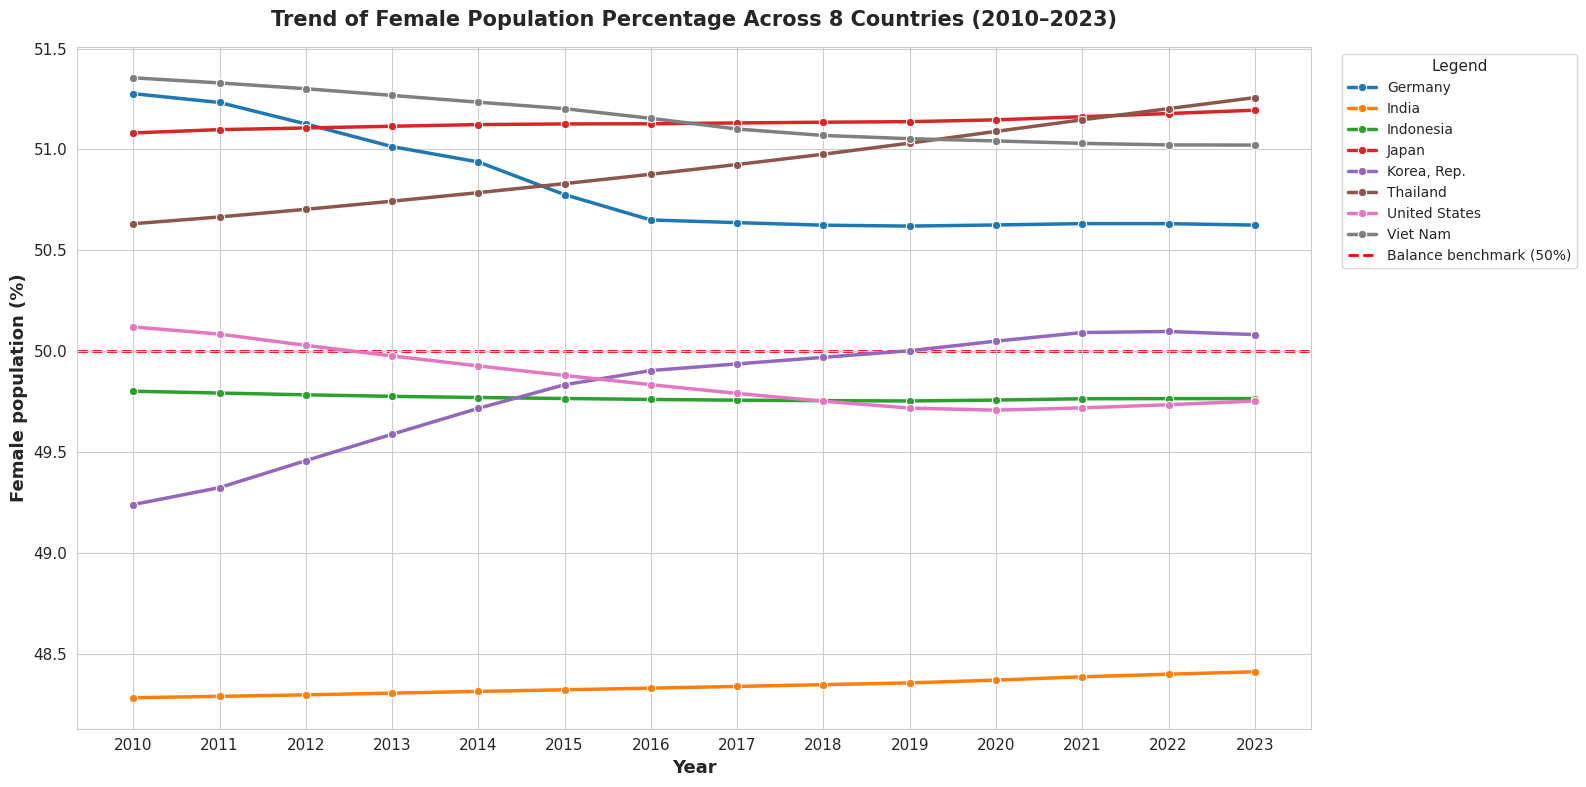

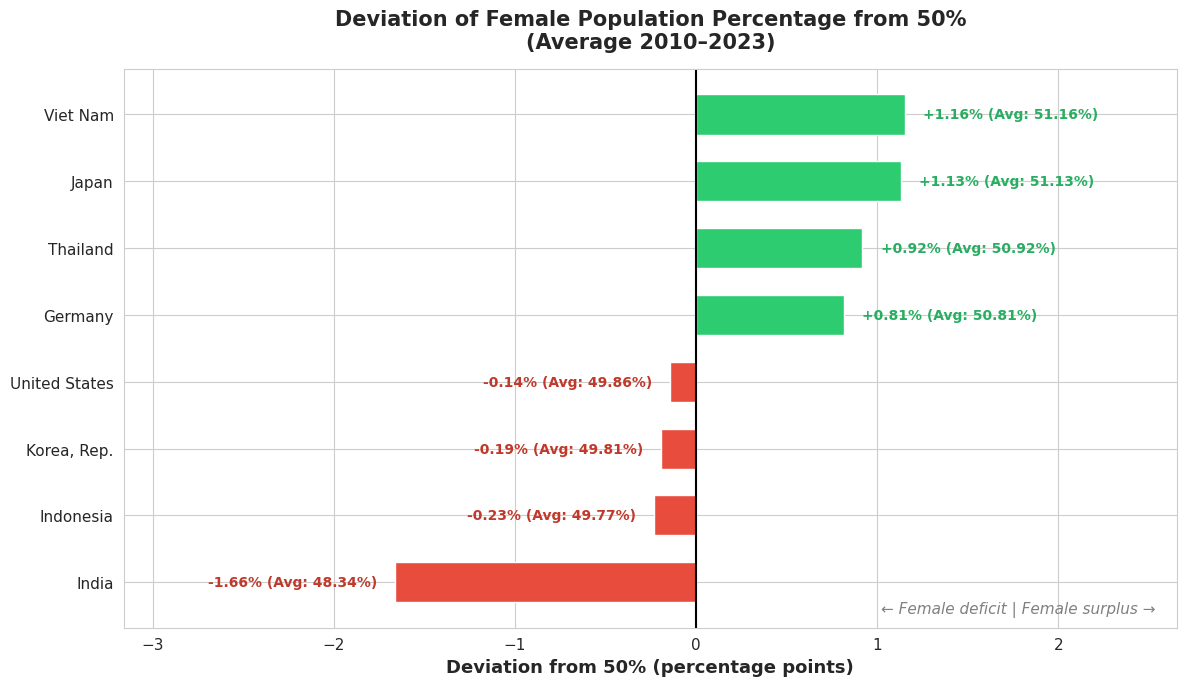

In [ ]:
# ====== CHART 3: LINE CHART — Female Population Percentage Over Time ======

pop_df = scatter_df.copy()

plt.figure(figsize=(16, 8))

palette = sns.color_palette('tab10', n_colors=len(pop_df['Country Name'].unique()))
ax = sns.lineplot(
    data=pop_df,
    x='Year', y='female_pop',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5
)

# Reference line at 50%
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Balance benchmark (50%)', zorder=0)

plt.title('Trend of Female Population Percentage Across 8 Countries (2010–2023)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Female population (%)', fontsize=13, fontweight='bold')
plt.xticks(range(2010, 2024))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Legend',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# ====== CHART 4: DEVIATION CHART — Deviation from 50% ======

# Calculate average deviation over 2010-2023 for each country
dev_df = pop_df.groupby('Country Name')['female_pop'].mean().reset_index()
dev_df['deviation'] = dev_df['female_pop'] - 50
dev_df = dev_df.sort_values('deviation', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

# Draw deviation bars
colors = ['#e74c3c' if d < 0 else '#2ecc71' for d in dev_df['deviation']]
bars = ax.barh(dev_df['Country Name'], dev_df['deviation'], color=colors, height=0.6, edgecolor='white')

# Zero reference line
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')

# Annotate values
for i, (val, fem) in enumerate(zip(dev_df['deviation'], dev_df['female_pop'])):
    sign = '+' if val >= 0 else ''
    ax.text(val + (0.1 if val >= 0 else -0.1), i,
            f'{sign}{val:.2f}% (Avg: {fem:.2f}%)',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold',
            color='#27ae60' if val >= 0 else '#c0392b')

plt.title('Deviation of Female Population Percentage from 50%\n(Average 2010–2023)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Deviation from 50% (percentage points)', fontsize=13, fontweight='bold')
plt.ylabel('')

# Extend x-axis to avoid overlap with labels
x_min = dev_df['deviation'].min()
x_max = dev_df['deviation'].max()
ax.set_xlim(x_min - 1.5, x_max + 1.5)

# Add annotation
ax.text(0.98, 0.02, '← Female deficit | Female surplus →',
        transform=ax.transAxes, fontsize=11, ha='right', va='bottom',
        style='italic', color='gray')

plt.tight_layout()
plt.show()

### Conclusion

#### A. Countries with Female Share Above 50%
- **Thailand (~50.6–51.3%) and Viet Nam (~51.0–51.4%):** The female share naturally exceeds the male share. However, their trajectories differ: Thailand exhibits a **slightly increasing trend**, whereas Viet Nam shows a **slight decrease** over the 25-year timeline.  
- **Japan (~51.1–51.2%) and Germany (~50.6–51.3%):** The consistently high female share in these developed nations heavily reflects their higher female life expectancy and rapidly aging populations (where women tend to outlive men). Notably, Germany shows a **gradual decline toward the 50% mark**, indicating a shift toward a more balanced overall population structure.

#### B. Countries with Female Share Below 50%
- **India (~48.3–48.4%):** India records the **lowest female share** in the entire group. This significant negative deviation strongly reflects a longstanding cultural **preference for sons** and historical gender-biased demographics. Fortunately, a **slight upward trend** in recent years suggests a gradual, albeit slow, societal improvement.
- **Indonesia (~49.8%):** Hovering just below the parity line, Indonesia demonstrates a **relatively balanced population structure** without extreme gender skewing.
- **Korea (Rep.) (~49.2% → 50.1%):** This is the **most notable transformational case**. The female share successfully rose from a deficit (49.2%) to officially cross the parity threshold (>50%) around 2019. This structural crossover reflects **significant socio-cultural improvements** regarding gender balance and the eradication of past son-preference practices in South Korea.
- **United States (~49.7–50.1%):** The US remains tightly bound to the 50% parity line, experiencing only a **slight decline** from just above 50% to slightly below in recent years.

#### Overall
- **The Biological Baseline:** Demographically, **~50%** is considered the natural biological parity. Persistent deviations from this baseline, particularly the severe negative deviation seen in **India**, serve as clear indicators of underlying **structural gender inequality** and social biases.
- **The Macro Convergence:** The overarching 25-year trend demonstrates that most outlier countries are **gradually converging toward the 50% balance line**. This macroeconomic convergence strongly suggests that gender equality in population demographics is **steadily improving on a global scale**.

---

### Objective 10: Labor Force Participation Trends: Females vs. Males

#### Metrics

**Group 1: Labor Force Participation Rate**

**`SL.TLF.CACT.FE.ZS` - Labor force participation rate, female (% of female population ages 15+)**
* This indicator measures the proportion of women aged 15 and older who are economically active (supplying labor for the production of goods and services). Data is an estimated model provided by the *International Labour Organization (ILO)*.
* Calculation method: **([Number of employed women] + [Number of unemployed women actively looking for work]) / [Total female population aged 15 and older] * 100**
* Reason for choosing this metric: Reflects the extent to which women directly participate in the market economy rather than being confined to unpaid domestic work.
* **Note:** The "Labor Force" strictly excludes women doing full-time homemaking (informal, unpaid care work).

**`SL.TLF.CACT.MA.ZS` - Labor force participation rate, male (% of male population ages 15+)**
* This indicator measures the proportion of men aged 15 and older who are economically active. Data is provided by the *ILO*.
* Calculation method: **([Number of employed men] + [Number of unemployed men actively looking for work]) / [Total male population aged 15 and older] * 100**
* Reason for choosing this metric: Serves as the ultimate comparative baseline. By comparing the female rate against the male rate in the same country, we can directly quantify the "Gender Participation Gap."


**Group 2: Employment Structure and Stability**

**`SL.AGR.EMPL.FE.ZS` / `SL.IND.EMPL.FE.ZS` / `SL.SRV.EMPL.FE.ZS` - Employment in agriculture/industry/services, female (% of female employment)**
* These indicators measure the distribution of the actively employed female workforce across the three broad economic sectors. Data is provided by the *ILO*.
* Calculation method: **[Number of women employed in the specific sector] / [Total number of employed women] * 100**
* Reason for choosing this metric: Allows us to track the structural macroeconomic shift of female labor (e.g., from traditional, subsistence-based agriculture to modern, value-added services).
* **Note:** The sum of these three sectoral percentages naturally equals 100% of total female employment.

**`SL.EMP.WORK.FE.ZS` - Wage and salaried workers, female (% of female employment)**
* This indicator measures the percentage of employed women who hold "paid employment jobs" (jobs with explicit or implicit contracts that provide a basic remuneration independent of the enterprise's revenue). Data is provided by the *ILO*.
* Calculation method: **[Number of female wage and salaried workers] / [Total female employment] * 100**
* Reason for choosing this metric: This acts as the primary proxy for job quality, formality, and financial stability. 
* **Note:** A rising trend in this metric signifies that women are successfully integrating into the formal corporate and institutional workforce.

**Group 3: Education and Employment Risk**

**`SE.TER.ENRR.FE` - School enrollment, tertiary, female (% gross)**
* This indicator measures the ratio of total female students enrolled in tertiary education (universities, colleges), regardless of age, to the female population of the age group that officially corresponds to that level. Data is provided by the *UNESCO Institute for Statistics (UIS)*.
* Calculation method: **[Total female students in Tertiary education] / [Total female population in the official Tertiary school-age group] * 100**
* Reason for choosing this metric: Reflects the training capacity and the level of advanced knowledge accessible to a country's female workforce.
* **Note:** Because this is a **gross ratio**, it includes late enrollees or second-degree seekers. Therefore, this ratio can absolutely **exceed 100%** in developed countries with lifelong learning cultures.

**`SL.EMP.VULN.FE.ZS` - Vulnerable employment, female (% of female employment)**
* This indicator measures the percentage of employed women working as "own-account workers" (self-employed without employees) and "contributing family workers" (unpaid workers in a family business). Data is provided by the *ILO*.
* Calculation method: **([Female contributing family workers] + [Female own-account workers]) / [Total female employment] * 100**
* Reason for choosing this metric: This is the definitive measure of "employment risk". Vulnerable workers typically lack formal work arrangements, decent working conditions, and social security.
* **Note:** This metric is highly inversely correlated with the "Wage and salaried workers" metric. A high vulnerability rate signifies extreme economic precarity for women.


#### Charts


**Chart Type:** Multi-line chart comparing the female labor force participation rate across the 6 representative countries, combined with a Baseline representing the global male average.
* **Reason for choosing this chart:** To examine the continuous temporal trends and the gender gap over a 25-year period (2000-2024), our group will use a **Multi-line chart** for the most intuitive and accurate representation. This chart not only helps us track the historical trajectory (growth, decline, or stagnation) of female labor force participation across 6 representative countries simultaneously, but also makes it easy to directly compare their performance against a benchmark (the dashed Global Male Average baseline) to clearly visualize how far each country is from gender parity over time.

**Chart Type:** Dumbbell Plot comparing the female labor force participation rate of 6 selected countries against the global male baseline (73.2%) in 2024.
* **Reason for choosing this chart:** To explicitly emphasize the absolute gender gap at our most recent data point (2024), our group chose the **Dumbbell Plot**. While line charts are excellent for showing historical trends, the Dumbbell plot is visually superior for highlighting the exact "distance" (the gap) between a specific country's female participation rate and the global male baseline. It instantly draws the viewer's eye to the magnitude and direction of the deficit (or surplus, as in Nigeria's case) for each country, making structural inequalities immediately obvious.

Number of valid records (6 countries): 1350
Years with available data: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Number of missing values (NaN): 0


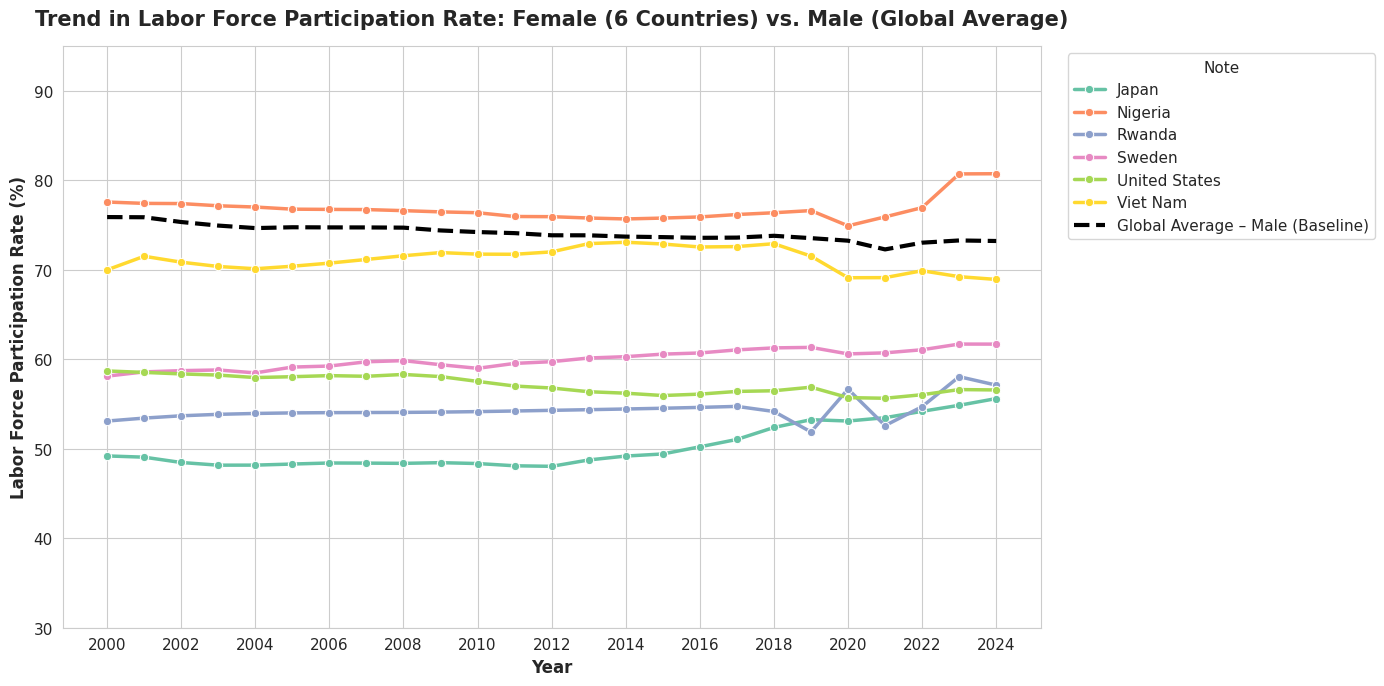

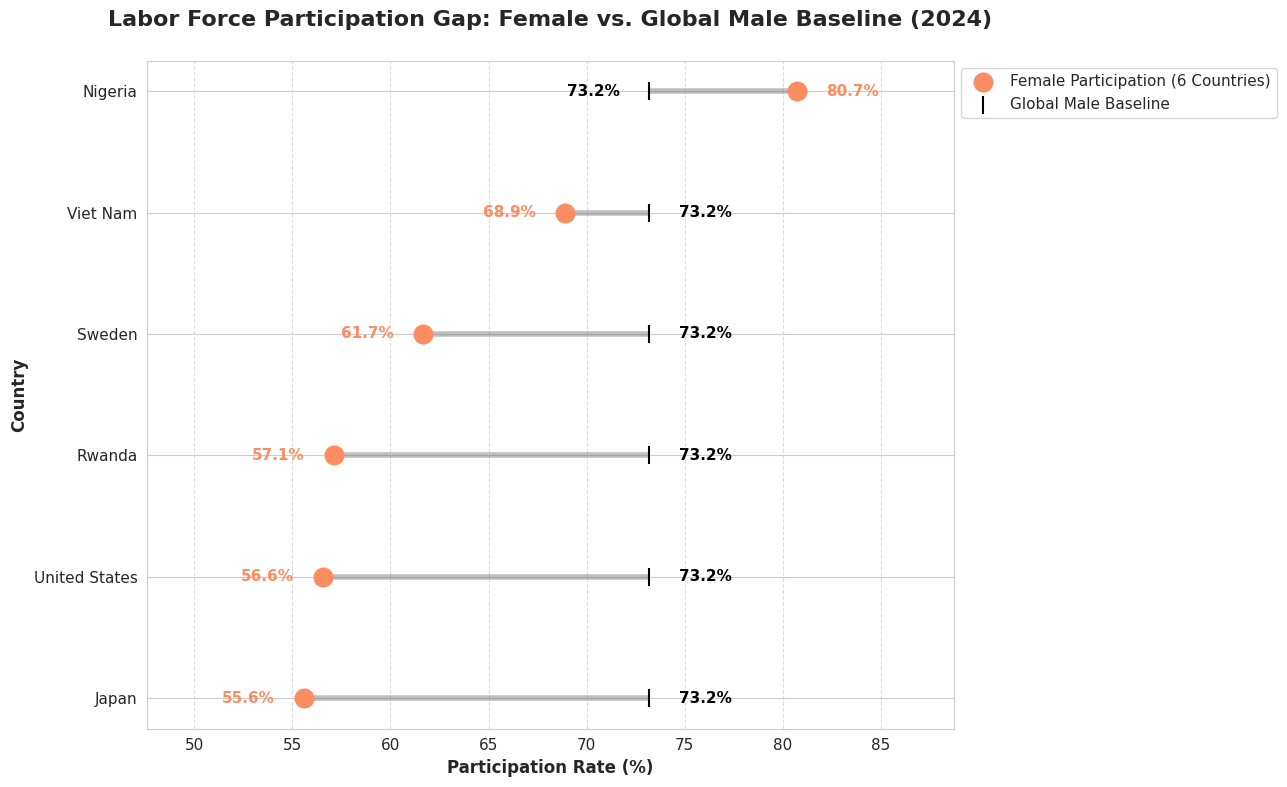

In [ ]:


df_raw = df_raw.copy()

# Danh sách các chỉ số cần dùng cho Câu hỏi 4
LABOR_INDICATORS = [
    'SL.TLF.CACT.FE.ZS', 'SL.TLF.CACT.MA.ZS', 
    'SL.AGR.EMPL.FE.ZS', 'SL.IND.EMPL.FE.ZS', 'SL.SRV.EMPL.FE.ZS', 
    'SL.EMP.WORK.FE.ZS', 'SE.TER.ENRR.FE', 'SL.EMP.VULN.FE.ZS'
]


labor_df = df_raw[df_raw['Series Code'].isin(LABOR_INDICATORS)].copy()


year_cols = [c for c in labor_df.columns if c.startswith('20') and c.endswith(']')]
labor_long = labor_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)


labor_long['Year'] = labor_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
labor_long['Value'] = pd.to_numeric(labor_long['Value'], errors='coerce')
labor_long = labor_long[labor_long['Year'] <= 2024].reset_index(drop=True)


SELECTED_COUNTRIES = ['NGA', 'RWA', 'SWE', 'USA', 'VNM', 'JPN']
labor_6_countries = labor_long[labor_long['Country Code'].isin(SELECTED_COUNTRIES)].copy()

labor_6_countries['Value'] = labor_6_countries.groupby(['Country Code', 'Series Code'])['Value'].transform(lambda x: x.interpolate(method='linear').ffill().bfill())


print(f"Number of valid records (6 countries): {len(labor_6_countries)}")
print(f"Years with available data: {sorted(labor_6_countries['Year'].unique())}")
print(f"Number of missing values (NaN): {labor_6_countries['Value'].isna().sum()}")

plt.figure(figsize=(14, 7))

# Tính trung bình toàn cầu cho Nam giới 
global_male_lfpr = labor_long[labor_long['Series Code'] == 'SL.TLF.CACT.MA.ZS'].groupby('Year')['Value'].mean().reset_index()

# Nữ giới của 6 quốc gia
female_lfpr_6c = labor_6_countries[labor_6_countries['Series Code'] == 'SL.TLF.CACT.FE.ZS']

# Vẽ đường cho 6 quốc gia (Nữ)
sns.lineplot(
    data=female_lfpr_6c, x='Year', y='Value', hue='Country Name', 
    marker='o', markersize=6, palette='Set2', linewidth=2.5
)

# Vẽ đường Baseline Trung bình Toàn cầu (Nam)
sns.lineplot(
    data=global_male_lfpr, x='Year', y='Value', 
    color='black', linestyle='--', linewidth=3, label='Global Average – Male (Baseline)'
)

plt.title('Trend in Labor Force Participation Rate: Female (6 Countries) vs. Male (Global Average)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Labor Force Participation Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(range(2000, 2025, 2))
plt.ylim(30, 95)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Note', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 4.3.2. Dumbbell Plot: Female Participation Gap to Global Male Baseline (2024)
latest_year = 2024
female_2024 = female_lfpr_6c[female_lfpr_6c['Year'] == latest_year].set_index('Country Name')['Value']
male_baseline_2024 = global_male_lfpr[global_male_lfpr['Year'] == latest_year]['Value'].values[0]

df_dumbbell = female_2024.sort_values().reset_index()
df_dumbbell['Male Baseline'] = male_baseline_2024

plt.figure(figsize=(13, 8))

plt.hlines(y=df_dumbbell['Country Name'], xmin=df_dumbbell[['Value', 'Male Baseline']].min(axis=1), 
        xmax=df_dumbbell[['Value', 'Male Baseline']].max(axis=1), 
        color='grey', alpha=0.5, linewidth=4, zorder=1)

# Vẽ điểm dữ liệu Nữ giới của 6 quốc gia
plt.scatter(df_dumbbell['Value'], df_dumbbell['Country Name'], 
            color='#FC8D62', s=180, label='Female Participation (6 Countries)', zorder=3)

# Vẽ điểm dữ liệu Nam giới (Global Baseline)
plt.scatter(df_dumbbell['Male Baseline'], df_dumbbell['Country Name'], 
            color='black', s=180, label='Global Male Baseline', marker='|', zorder=3)


plt.title(f'Labor Force Participation Gap: Female vs. Global Male Baseline ({latest_year})', 
        fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Participation Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Country', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.legend(frameon=True, fontsize=11, loc='upper left', bbox_to_anchor=(1, 1))


min_val = df_dumbbell[['Value', 'Male Baseline']].min().min()
max_val = df_dumbbell[['Value', 'Male Baseline']].max().max()
plt.xlim(min_val - 8, max_val + 8)


offset = 1.5
for i, row in df_dumbbell.iterrows():
    ha_f = 'right' if row['Value'] <= row['Male Baseline'] else 'left'
    x_f = row['Value'] - offset if row['Value'] <= row['Male Baseline'] else row['Value'] + offset
    plt.text(x_f, row['Country Name'], f"{row['Value']:.1f}%", 
            va='center', ha=ha_f, color='#FC8D62', fontweight='bold', fontsize=11)

    ha_m = 'left' if row['Male Baseline'] > row['Value'] else 'right'
    x_m = row['Male Baseline'] + offset if row['Male Baseline'] > row['Value'] else row['Male Baseline'] - offset
    plt.text(x_m, row['Country Name'], f"{row['Male Baseline']:.1f}%", 
            va='center', ha=ha_m, color='black', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

#### Conclusion
* **Global Male Baseline (Dashed Black Line):** Remained highly stable (around 73-75%) over the two decades, indicating consistent economic participation by men globally.
* **Nigeria and Viet Nam:** Nigeria records the highest female labor participation rate (ranging from 75% to over 80% recently), consistently surpassing the global male average. Viet Nam follows closely, maintaining a high and stable rate of around 70-72%.
* **Sweden, USA, Japan, and Rwanda:** These countries cluster in the 50-60% range. Notably, Japan shows a steady upward trend from 2012 onwards, reflecting the success of policies designed to bring women back into the workforce. Conversely, the United States displays a slow but gradual decline in female participation over the same 24-year period.


---

### Objective 11: Shift in Employment Structure and Wage/Salaried Rates (Global Average)


#### Metrics

**`SL.AGR.EMPL.FE.ZS` - Employment in agriculture, female (% of female employment)**
* This indicator measures the share of employed women who work in the agricultural sector (including farming, hunting, forestry, and fishing). Data is an estimated model provided by the *International Labour Organization (ILO)*.
* Calculation method: **[Number of women employed in agriculture] / [Total number of employed women] * 100**
* Reason for choosing this metric: This indicator helps evaluate the proportion of the female workforce engaged in traditional, primary-sector jobs, which often correlate with lower income, seasonal instability, and higher physical vulnerability.
* **Note:** A persistent decrease in this metric over time usually signals a successful macroeconomic structural transformation and ongoing urbanization.

**`SL.IND.EMPL.FE.ZS` - Employment in industry, female (% of female employment)**
* This indicator measures the share of employed women who work in the industrial sector (including mining, manufacturing, construction, and public utilities). Data is provided by the *International Labour Organization (ILO)*.
* Calculation method: **[Number of women employed in industry] / [Total number of employed women] * 100**
* Reason for choosing this metric: It reflects the integration of women into the manufacturing and heavy industrial base of the economy.
* **Note:** In many developing countries, structural shifts often see women bypassing heavy industry to move straight from agriculture into services, meaning this industrial share might remain relatively small or stagnant compared to the male workforce.

**`SL.SRV.EMPL.FE.ZS` - Employment in services, female (% of female employment)**
* This indicator measures the share of employed women who work in the services sector (encompassing wholesale/retail trade, restaurants, transport, finance, real estate, healthcare, and education). Data is provided by the *International Labour Organization (ILO)*.
* Calculation method: **[Number of women employed in services] / [Total number of employed women] * 100**
* Reason for choosing this metric: The services sector is universally the primary engine of modern job creation for women. Tracking this expansion quantifies the successful integration of women into the modern, urban, and knowledge-based economy.
* **Note:** The combined sum of Agriculture, Industry, and Services employment percentages will consistently equal 100% of the total actively employed female workforce.

**`SL.EMP.WORK.FE.ZS` - Wage and salaried workers, female (% of female employment)**
* This indicator measures the percentage of employed women who hold "paid employment jobs" (defined as jobs with explicit or implicit written/oral contracts that provide basic, predictable remuneration). Data is provided by the *International Labour Organization (ILO)*.
* Calculation method: **[Number of female wage and salaried workers] / [Total number of employed women] * 100**
* Reason for choosing this metric: This acts as our definitive proxy for job quality, formality, and financial stability. It tests whether sectoral shifts (e.g., moving to services) actually translate into better, more secure livelihoods for women.
* **Note:** This metric stands in direct opposition to "Vulnerable employment" (informal, self-employed, or unpaid family workers). A rising wage and salaried rate is the strongest indicator of increasing economic empowerment and financial independence.


#### Charts

**Chart Type:** Stacked Area Chart illustrating the agriculture-industry-services composition, overlaid with a Line Chart showing the percentage of female wage and salaried workers.
* **Reason for choosing this chart:** To comprehensively visualize the structural transformation of the female labor force and its direct impact on job stability, our group combined two powerful visual elements into a dual-axis chart. The **Stacked Area Chart** is ideal for displaying a "part-to-whole" relationship over time, clearly illustrating how the workforce transitions across the three core economic sectors (Agriculture, Industry, Services) within a 100% boundary. Overlaying the **Line Chart** on a secondary axis allows us to simultaneously track the "Wage and Salaried Workers" rate. This specific combination enables the viewer to instantly evaluate the macroeconomic correlation: as women move out of agriculture and into services, we can definitively see if that sectoral shift translates into higher job security and formal financial independence.

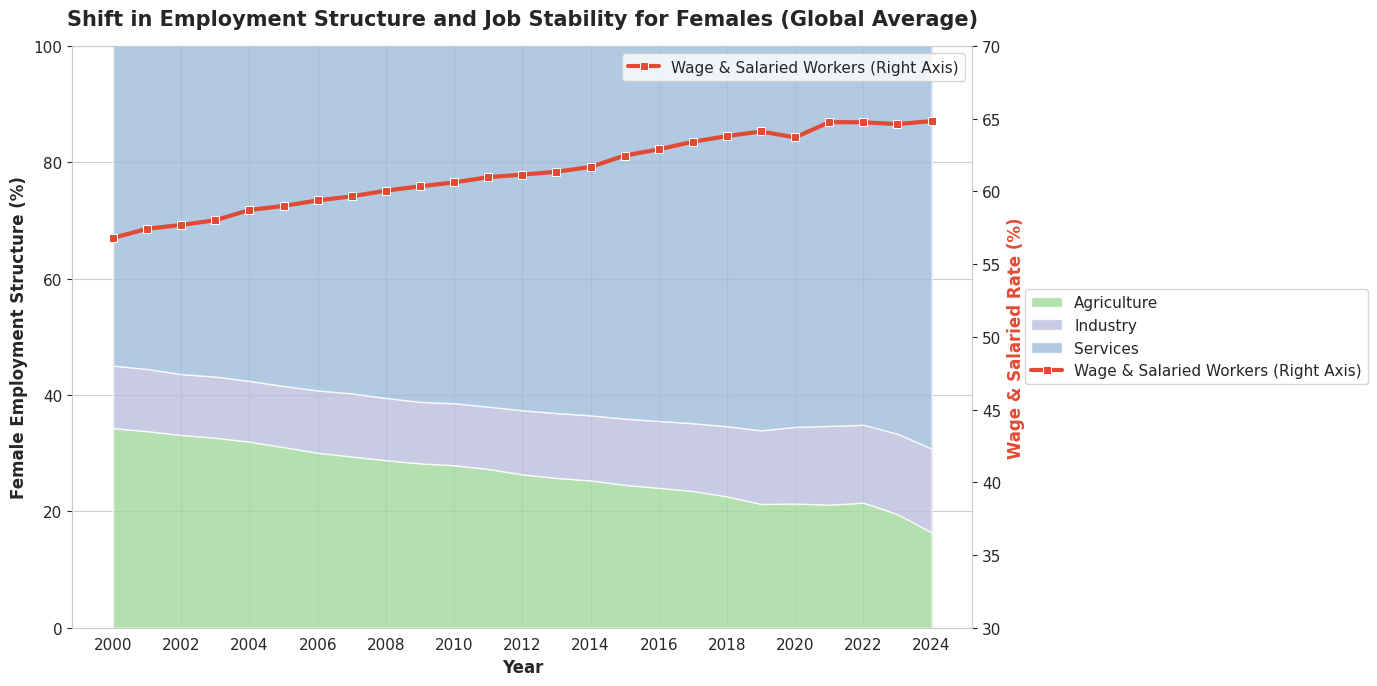

In [ ]:
indicators = ['SL.AGR.EMPL.FE.ZS', 'SL.IND.EMPL.FE.ZS', 'SL.SRV.EMPL.FE.ZS', 'SL.EMP.WORK.FE.ZS']


global_structure = labor_long[labor_long['Series Code'].isin(indicators)].groupby(['Year', 'Series Code'])['Value'].mean().unstack().reset_index()

for indicator in indicators:
    if indicator not in global_structure.columns:
        global_structure[indicator] = 0

global_structure = global_structure.dropna()

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.stackplot(global_structure['Year'], 
              global_structure['SL.AGR.EMPL.FE.ZS'], 
              global_structure['SL.IND.EMPL.FE.ZS'], 
              global_structure['SL.SRV.EMPL.FE.ZS'], 
              labels=['Agriculture', 'Industry', 'Services'], 
              colors=['#a1d99b', '#bcbddc', '#9ebcda'], alpha=0.8)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Female Employment Structure (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_xticks(range(2000, 2025, 2))

ax2 = ax1.twinx()
sns.lineplot(data=global_structure, x='Year', y='SL.EMP.WORK.FE.ZS', 
             color='#e34a33', marker='s', linewidth=3, ax=ax2, label='Wage & Salaried Workers (Right Axis)')

ax2.set_ylabel('Wage & Salaried Rate (%)', fontsize=12, fontweight='bold', color='#e34a33')
ax2.set_ylim(30, 70) 
ax2.grid(False) 

# Combine Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', bbox_to_anchor=(1.05, 0.5))

plt.title('Shift in Employment Structure and Job Stability for Females (Global Average)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### Conclusion

* **Dominance and Expansion of the Services Sector:** The blue area (Services) consistently expands over the years, eating heavily into the Agriculture sector (green area), which shrinks from over 30% down to roughly 15%. The Industrial sector (purple) remains relatively thin and stagnant. This highlights a global urbanization trend pulling women from the fields into the service economy.
* **Correlation with Job Stability:** The red line (Wage and Salaried Workers) trends upward from under 60% to approximately 65%, moving in parallel with the growth of the services sector. This structural shift has brought a positive impact: Women are transitioning from self-sufficient rural labor to contracted, salaried positions, thereby increasing their financial independence.

---

### Objective 12: Impact of Tertiary Education on Female Employment Risk


#### Metrics

**`SE.TER.ENRR.FE` - School enrollment, tertiary, female (% gross)**
* This indicator measures the ratio of total female students enrolled in tertiary education (including universities, colleges, and advanced research programs), regardless of age, to the female population of the age group that officially corresponds to the tertiary level of education (usually ages 18-22). Data is provided by the *UNESCO Institute for Statistics (UIS)*.
* Calculation method: **[Total female students enrolled in Tertiary education of all ages] / [Total female population in the official Tertiary school-age group] * 100**
* Reason for choosing this metric: This indicator directly reflects the training capacity, professional skill level, and access to advanced knowledge for the female workforce. It is the key determinant of a woman's ability to transition into high-value, formal jobs.
* **Note:** Because this is a **gross ratio**, the numerator includes students of any age (including late enrollees, adult learners, or second-degree seekers), while the denominator is fixed to a specific youth age group. Therefore, this ratio can absolutely **exceed 100%** in developed countries with strong lifelong learning cultures.

**`SL.EMP.VULN.FE.ZS` - Vulnerable employment, female (% of female employment)**
* This indicator measures the percentage of employed women working as "own-account workers" (self-employed without employees) and "contributing family workers" (unpaid workers in a family business). Data is an estimated model provided by the *International Labour Organization (ILO)*.
* Calculation method: **([Female contributing family workers] + [Female own-account workers]) / [Total female employment] * 100**
* Reason for choosing this metric: This serves as the definitive measure of "employment risk". Vulnerable jobs typically lack formal work arrangements, stable income, decent working conditions, and completely bypass social security or safety nets.
* **Note:** This metric is highly inversely correlated with the "Wage and salaried workers" metric. A high vulnerability rate signifies extreme economic precarity and high dependency for women in that country.



#### Charts

**Chart Type:** Small Multiples (Grid) of Line Charts comparing Female Tertiary Education Enrollment (solid blue line) and Vulnerable Employment (dashed red line) across 6 representative countries from 2000 to 2024.
* **Reason for choosing this chart:** To analyze the long-term relationship between higher education and employment risk, our group utilized a **Small Multiples Line Chart** design. Line charts are the optimal choice for visualizing continuous time-series data over a 25-year span. By plotting both variables simultaneously for each country, we can explicitly observe the "scissor effect" (inverse correlation) where rising education levels drive down vulnerable employment. Furthermore, separating the countries into individual subplots (a grid) completely prevents visual clutter (the "spaghetti chart" effect), allowing for clean, isolated analysis of each nation's unique structural shift while still enabling macro-level cross-country comparisons.

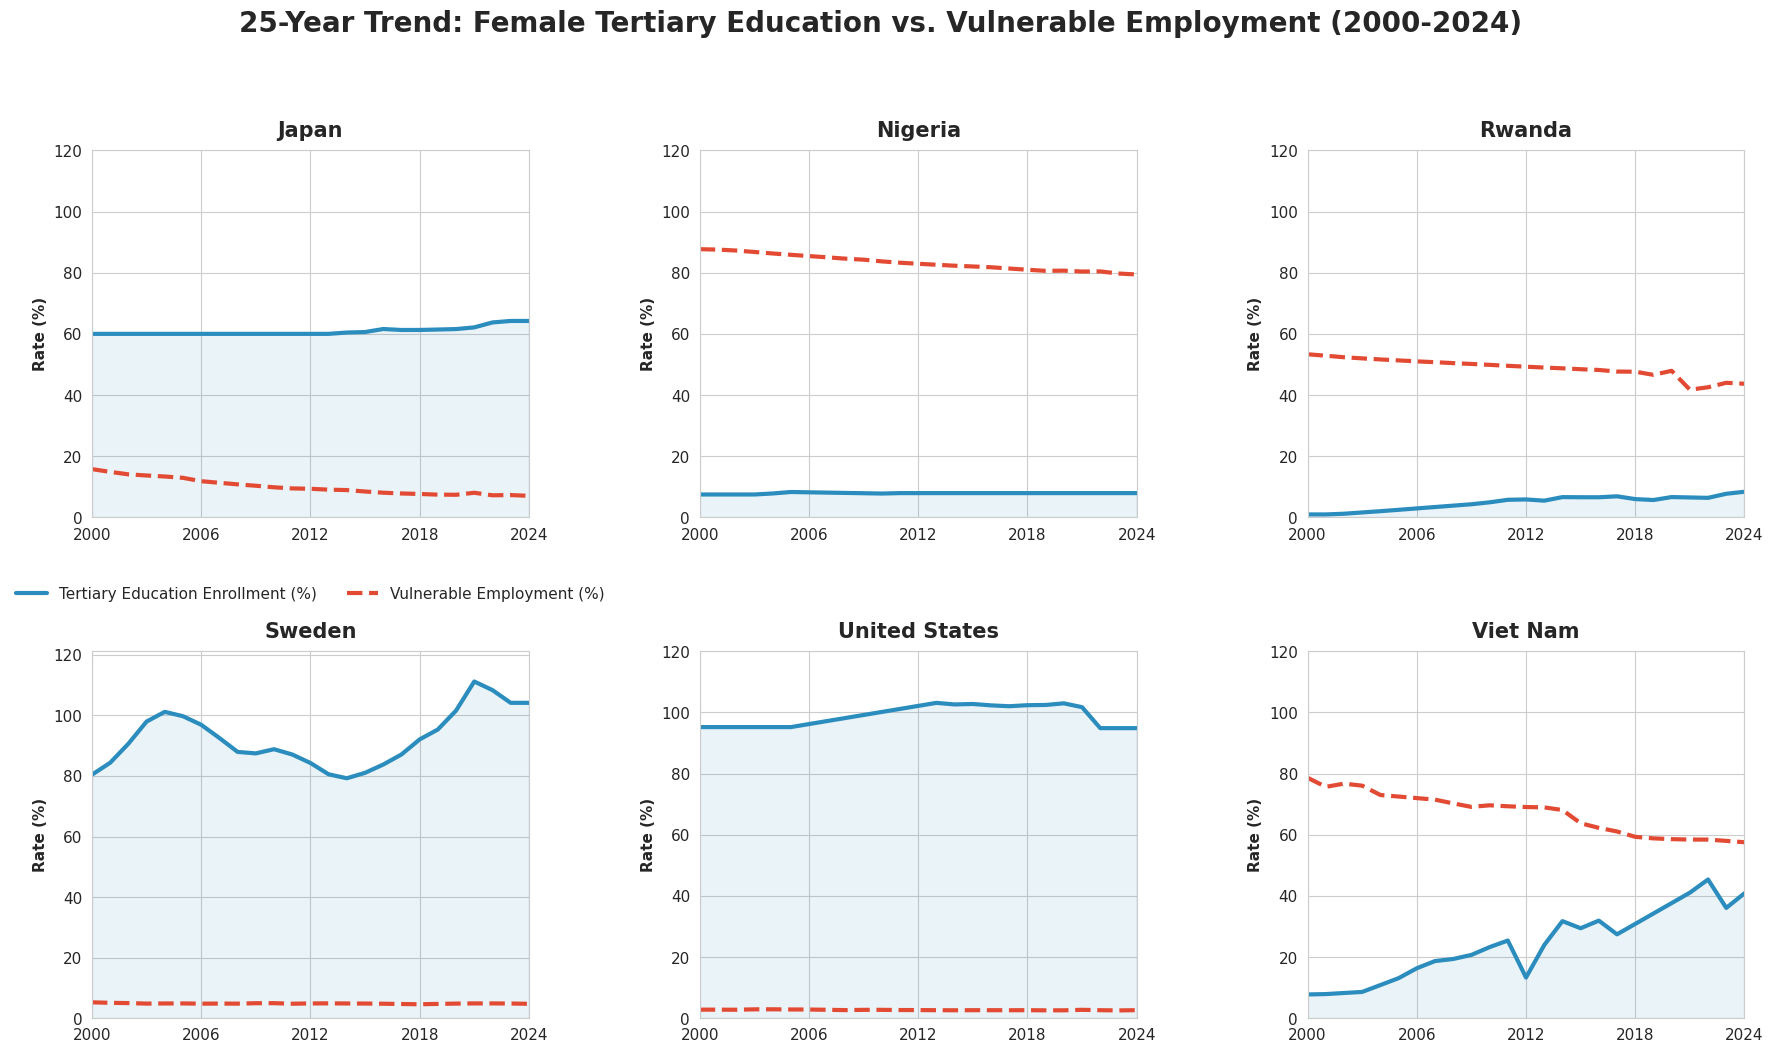

In [ ]:
INDICATORS = {
    'SE.TER.ENRR.FE': 'Tertiary_Edu',
    'SL.EMP.VULN.FE.ZS': 'Vulnerable_Emp'
}

edu_vuln_df = labor_long[labor_long['Series Code'].isin(INDICATORS.keys())].copy()

# Xóa trùng lặp
edu_vuln_df = edu_vuln_df.drop_duplicates(subset=['Country Name', 'Country Code', 'Series Code', 'Year'])

edu_vuln_df['Value'] = edu_vuln_df.groupby(['Country Name', 'Series Code'])['Value'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))


# Pivot data theo Năm (2000 - 2024)
pivot_trend = edu_vuln_df.pivot_table(index=['Country Name', 'Year'], 
                                      columns='Series Code', 
                                      values='Value', aggfunc='mean').reset_index()

pivot_trend.rename(columns=INDICATORS, inplace=True)
pivot_trend = pivot_trend.dropna(subset=['Tertiary_Edu', 'Vulnerable_Emp'])

# 2. Vẽ Lưới 6 Subplots
countries = pivot_trend['Country Name'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('25-Year Trend: Female Tertiary Education vs. Vulnerable Employment (2000-2024)', 
             fontsize=20, fontweight='bold', y=1.05)
axes = axes.flatten()

color_edu = '#2b8cbe'  # Xanh dương: Đại học
color_vuln = '#e34a33' # Đỏ: Việc làm tổn thương

for i, country in enumerate(countries):
    ax = axes[i]
    country_data = pivot_trend[pivot_trend['Country Name'] == country].sort_values('Year')
    
    # Vẽ đường Giáo dục Đại học
    line1, = ax.plot(country_data['Year'], country_data['Tertiary_Edu'], 
                     color=color_edu, linewidth=3, label='Tertiary Education Enrollment (%)')
    ax.fill_between(country_data['Year'], country_data['Tertiary_Edu'], color=color_edu, alpha=0.1)
    
    # Vẽ đường Việc làm dễ tổn thương
    line2, = ax.plot(country_data['Year'], country_data['Vulnerable_Emp'], 
                     color=color_vuln, linewidth=3, linestyle='--', label='Vulnerable Employment (%)')
    
    ax.set_title(country, fontsize=15, fontweight='bold', pad=10)
    ax.set_ylabel('Rate (%)', fontweight='bold')
    ax.set_ylim(0, max(120, country_data['Tertiary_Edu'].max() + 10)) # Trục Y chung từ 0 đến max
    ax.set_xlim(2000, 2024)
    ax.set_xticks([2000, 2006, 2012, 2018, 2024])
    
    if i == 0:
        ax.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

#### Conclusion

**1. Overview: The "Scissor Effect"**
Looking at the 25-year timeline, we can observe a stark inverse correlation between the two indicators. As the solid blue line (Tertiary Education) climbs, the dashed red line (Vulnerable Employment) is consistently driven down. This demonstrates that advanced education serves as the ultimate "ticket" for women to escape precarious, informal labor (such as subsistence farming or petty trade) and transition into the formal sector with stable contracts and salaries.

**2. Clustering Analysis (The 3 Country Profiles):**
* **The "Ceiling & Floor" Economies (US, Sweden, Japan):** Throughout the two decades, their female higher education rates have consistently hit the "ceiling" (ranging from 60% to over 100%), which in turn crushes the vulnerable employment rate to the "floor" (stabilized below 10%). In these developed nations, women are largely shielded from informal, high-risk work thanks to a robust knowledge-based foundation.
* **The "Active Transformation" (Viet Nam):** Viet Nam's chart most vividly illustrates the "X-shaped" structural shift. From 2000 to 2024, female tertiary enrollment skyrocketed from under 10% to over 40%. Simultaneously, vulnerable employment plummeted from nearly 80% to under 60%. This clearly reflects a new generation of women migrating from agricultural fields into corporate, manufacturing, and service sectors.
* **The "Informal Labor Trap" (Nigeria, Rwanda):** While Rwanda shows early signs of structural improvement, Nigeria represents a critical warning. Its female tertiary enrollment has flatlined at the bottom (under 10%) for two decades, leaving the vulnerable employment rate trapped at a staggering 80%+. Without access to higher education, breaking the cycle of informal labor remains virtually impossible.

**3. Key Takeaway:**
Investing in female tertiary education is far more than a social "Gender Parity" initiative; it is a profound **macroeconomic lever**. It actively restructures the labor market, permanently transitioning the female workforce from a state of "high-vulnerability, low-productivity" to "formal, high-productivity" employment.

---

### Objective 13: Evaluating the correlation between Educational attainment and the Female labor force

To measure the degree of **correlation** between **the female tertiary education enrollment rate** and **the female labor force participation rate on a global scale in the year 2020**. Our group chose 2020 because it is the recent milestone with available data for **many countries** in this regard.

This objective is set to track **how the rate of women appearing in the labor force changes as more women achieve higher education**.

#### Metrics

**`SE.TER.ENRR.FE` - School enrollment, tertiary, female (% gross)**
* This indicator measures the ratio of total female students enrolled in tertiary education (universities, colleges, post-secondary certificates), regardless of age, to the female population of the age group that officially corresponds to the tertiary level of education (usually the 18-22 age group). Data is provided by the *UNESCO Institute for Statistics (UIS)*.
* Calculation method: **[Total female students enrolled in Tertiary education of all ages] / [Total female population in the official Tertiary school-age group] * 100**
* Reason for choosing this metric: This indicator reflects the training capacity and higher-knowledge access level of a country's female workforce.
* **Note:** Because this is a **gross ratio**, the numerator includes students of any age (including late enrollees or second-degree seekers), while the denominator is fixed to a specific age group. Therefore, this ratio can absolutely **exceed 100%** in developed countries.

**`SL.TLF.CACT.FE.ZS` - Labor force participation rate, female (% of female population ages 15+)**
* This indicator measures the proportion of women aged 15 and older who are economically active (supplying labor for the production of goods and services during a specified period). Data is an estimated model provided by the *International Labour Organization (ILO)*.
* Calculation method: **([Number of employed women] + [Number of unemployed women actively looking for work]) / [Total female population aged 15 and older] * 100**
* Reason for choosing this metric: This indicator reflects the extent to which women directly participate in and contribute to the market economy rather than being confined to the domestic household economy.
* **Note:** The concept of "Labor Force" includes those actively seeking work, but **strictly excludes** women doing full-time homemaking (unpaid, informal work).

#### Charts
**Chart type:** Scatter plot combined with a regression trendline.

- **Reason for choosing this chart**: To examine the correlation between two quantitative variables (Tertiary enrollment rate vs. Labor force participation rate) that we have the data of **87 countries for the year 2020**, our group will use a **Scatter plot** for the most intuitive and accurate representation. This chart not only helps us see the general trend (via the regression line) but also makes it easy to spot outliers - meaning countries that defy standard norms.

Number of countries with complete data for both indicators in 2020: 89 countries


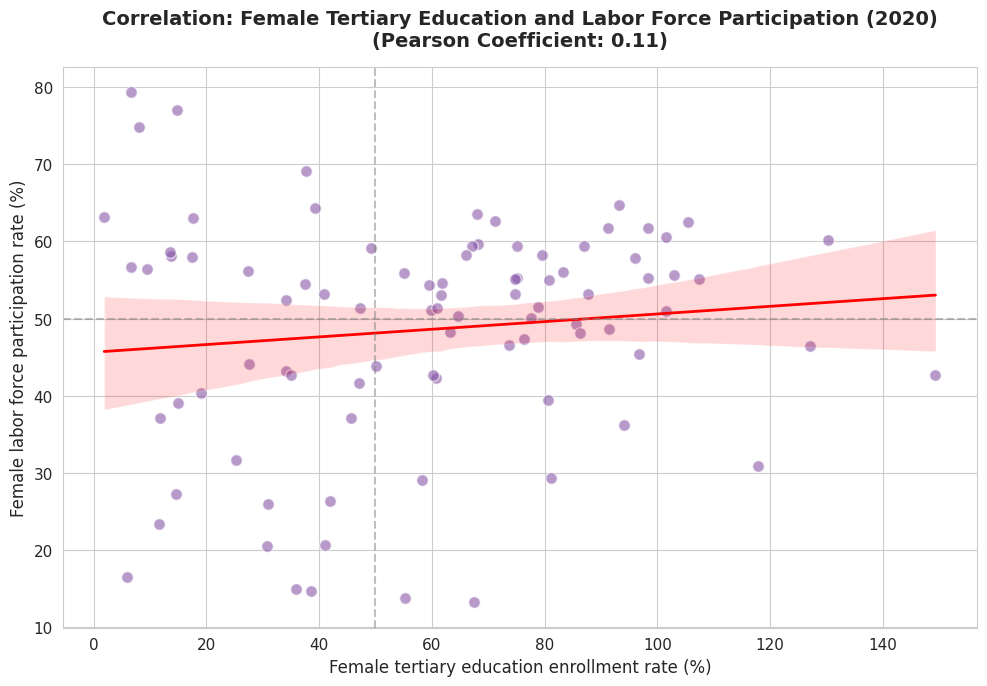

In [ ]:
INDICATORS_Q3 = {
    'SE.TER.ENRR.FE': 'Female_Tertiary_Edu',
    'SL.TLF.CACT.FE.ZS': 'Female_Labor_Force'
}

TARGET_YEAR_Q3 = '2020 [YR2020]'

corr_df3 = df_raw[df_raw['Series Code'].isin(INDICATORS_Q3.keys())].copy()

corr_df3 = corr_df3[['Country Name', 'Country Code', 'Series Code', TARGET_YEAR_Q3]]
corr_df3.rename(columns={TARGET_YEAR_Q3: 'Value'}, inplace=True)

# Convert data types 
corr_df3['Value'] = pd.to_numeric(corr_df3['Value'], errors='coerce')

# Transform table structure (ĐÃ XÓA 'Year' TRONG INDEX)
pivot_df3 = corr_df3.pivot_table(index=['Country Name'], 
                                 columns='Series Code', 
                                 values='Value', aggfunc='mean').reset_index()

# Rename Series Codes to understandable names
pivot_df3.rename(columns=INDICATORS_Q3, inplace=True)

# Drop countries missing either of the 2 indicators
corr_clean3 = pivot_df3.dropna(subset=['Female_Tertiary_Edu', 'Female_Labor_Force']).copy()

print(f"Number of countries with complete data for both indicators in 2020: {len(corr_clean3)} countries")

plt.figure(figsize=(10, 7))

# Calculate Pearson correlation coefficient
corr_edu_labor = corr_clean3['Female_Tertiary_Edu'].corr(corr_clean3['Female_Labor_Force'])

# Draw scatter plot with regression line
import seaborn as sns
sns.regplot(data=corr_clean3, x='Female_Tertiary_Edu', y='Female_Labor_Force', 
            scatter_kws={'alpha':0.6, 'color':'#8856a7', 'edgecolor':'w', 's':70}, 
            line_kws={'color':'red', 'linewidth':2})

plt.title(f'Correlation: Female Tertiary Education and Labor Force Participation (2020)\n(Pearson Coefficient: {corr_edu_labor:.2f})', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Female tertiary education enrollment rate (%)', fontsize=12)
plt.ylabel('Female labor force participation rate (%)', fontsize=12)

# Add reference lines to divide quadrants
plt.axvline(50, color='gray', linestyle='--', alpha=0.5) # 50% university mark
plt.axhline(50, color='gray', linestyle='--', alpha=0.5) # 50% working mark

plt.tight_layout()
plt.show()

#### Conclusion

Based on the scatter plot above, our group deduces the following analyses:
* With a Pearson coefficient reaching only 0.16, the regression trendline (red) runs almost horizontally, indicating an **extremely weak correlation**. Data dots are chaotically spread across the entire graph rather than hugging the trendline. This partly proves a truth: **A high rate of women enrolling in tertiary education does not mean they will participate more in the labor force**.
* Using the 2 gray dashed reference lines (the 50% marks), the chart displays a clear division into **4 quadrants**, featuring the following notable points:
    * **Top-left quadrant**: There is a large number of countries with **very low female tertiary enrollment (only 10-30%) but skyrocketing labor participation rates (60-80%)**. These are predominantly agricultural or low-income economies where women are forced into manual labor to survive, even without degrees.
    * **Bottom-right quadrant**: This is the most remarkable area. Many countries boast **extremely high female tertiary enrollment (60%, 80%, even exceeding 100%) but their working rate falls below 40%, sometimes even dropping to 15-20%**. This indicates that women in these nations have excellent access to knowledge but face some barrier preventing them from stepping out to work.
    * **Top-right quadrant (the ideal scenario)**: There remains a cluster of countries that **satisfy both factors (over 50% studying and over 50% working)**. These are usually developed countries with robust social welfare systems.


**General Comments**

This chart has exposed a global **educational paradox** regarding women: *A university degree is a necessary condition to elevate human capital quality, but it is absolutely **not sufficient** to liberate female labor.*

The data shows that in many countries, even though the education system is extremely open (female tertiary students dominate), upon graduation, they vanish from the labor market. It is highly likely that barriers such as patriarchy, religious prejudices, lack of childcare facilities, or economies failing to create enough suitable jobs... have shackled these highly educated women. This represents a massive waste of human capital for the economy.

**Limitations of the Analysis**

Although the chart successfully reflects certain paradox, this analysis still faces a few hurdles regarding data specification:

* The `SL.TLF.CACT.FE.ZS` indicator on the Y-axis includes all forms of labor: from corporate CEOs to freelancers, street vendors, and subsistence agriculture workers. Therefore, in poor countries, the fact that women have a very high working rate (top-left of the chart) does not mean they have good jobs or high gender equality; it's simply the force of economic circumstances. **This creates significant noise when compared to the proportion holding university degrees.**
* The X-axis features countries **exceeding the 100% mark** (some even reaching up to 140%). This is a characteristic of the **gross enrollment ratio** (which counts older women returning to study, second-degree seekers, and late enrollees). **This causes the data to not 100% accurately reflect the proportion of college-age female youth currently in higher education.**

---

### Objective 14: Assessing the proportion of parliamentary seats held by women in countries around the world.

To assess **the overall picture of the distribution of parliamentary seats held by women globally in 2020** (our group chose 2020 because it is the recent milestone with available data for **many countries** in this regard), while comparing the trends of this indicator in six representative countries across continents (Rwanda, Sweden, the United States, Vietnam, Japan, and Nigeria) between 2000 and 2024.

Combining a spatial perspective (global map) and a temporal perspective (24-year trends) will provide the most comprehensive assessment of women's participation in politics worldwide, and in the countries whose trends are examined.

#### Metrics

**`SG.GEN.PARL.ZS` - Proportion of seats held by women in national parliaments (%)**
* This indicator measures the percentage of seats held by women in a single-chamber parliament or the lower chamber of a bicameral parliament. For example, in Vietnam, it represents the percentage of female members in the Vietnam National Assembly. Data is provided by the *Inter-Parliamentary Union (IPU)*.
* Calculation method: **[Total seats held by women in the Lower Chamber/Parliament] / [Total seats in the Lower Chamber/Parliament] * 100**
* Reason for choosing this metric: This indicator reflects the level of women's political participation in different countries.
* **Note:** This indicator **does not** include seats in the Upper house or local governments.

#### Charts

**Chart:** Line chart, color-coded by country.
- **Reason for choosing this chart:** After examining the overall spatial picture, we used a **multi-line chart** to go into the detail. This chart helps compare the rate of change (slope) over 24 years for six representative countries across different continents.

In [ ]:
year_cols =[c for c in df_raw.columns if c.startswith('20') and c.endswith(']')]
parl_all = df_raw[df_raw['Series Code'] == 'SG.GEN.PARL.ZS'].copy()

parl_long = parl_all.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)
parl_long['Year'] = parl_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
parl_long['Value'] = pd.to_numeric(parl_long['Value'], errors='coerce')

# Lọc riêng dữ liệu cho 6 quốc gia
SELECTED_COUNTRIES = ['RWA', 'NGA', 'SWE', 'USA', 'VNM', 'JPN']
parl_case_study = parl_long[(parl_long['Country Code'].isin(SELECTED_COUNTRIES)) & (parl_long['Year'] <= 2024)].copy()

parl_clean = parl_case_study.copy()
parl_with_data = parl_clean.dropna(subset=['Value']).copy()

# find missing values 
parl_clean[parl_clean['Value'].isna()]


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
106,United States,USA,Proportion of seats held by women in national ...,SG.GEN.PARL.ZS,2000 [YR2000],NaN,2000


Since the data is missing only 1 value belonging to the USA in the first year of our observation period, our group will leave that cell empty without applying any further data imputation.

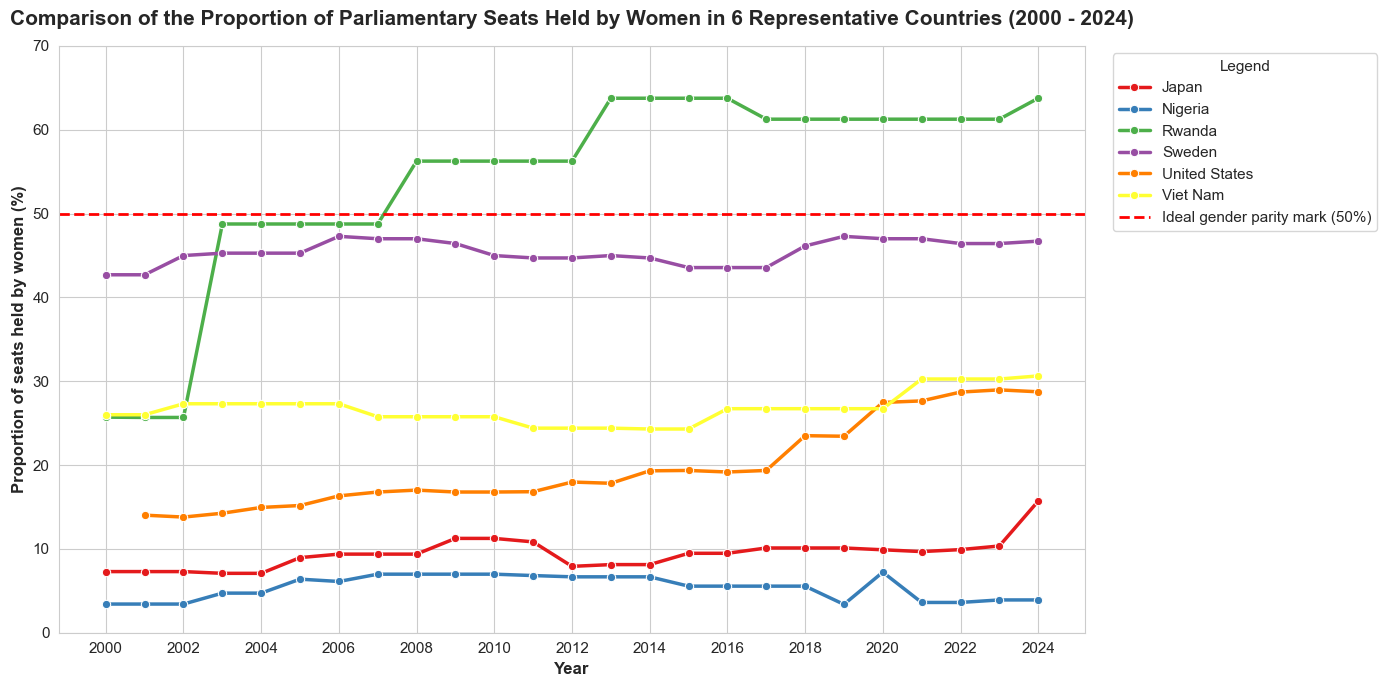

In [ ]:
plt.figure(figsize=(14, 7))

# Draw line chart
sns.lineplot(
    data=parl_clean,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette='Set1', 
    linewidth=2.5
)

# Add reference line for the 50% mark
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Ideal gender parity mark (50%)')

plt.title('Comparison of the Proportion of Parliamentary Seats Held by Women in 6 Representative Countries (2000 - 2024)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Proportion of seats held by women (%)', fontsize=12, fontweight='bold')

plt.xticks(range(2000, 2025, 2))
plt.ylim(0, 70) 

# Custom Legend
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, title='Legend', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

#### Conclusion

Based on the chart, our group has drawn several analytical points regarding the 6 countries:

* **Rwanda's line is the most remarkable feature of the entire chart.** Starting at over 25% in 2000, Rwanda experienced a vertical leap approaching 50% in 2003, and continued to break through to the highest level in the world (over 60%) from 2013 to the present. Rwanda is the only country in the group to surpass the ideal 50% mark (the red dashed line). The core reason is that the country's new Constitution in 2003 mandated a strict "gender quota" policy of a minimum of 30% for women, transforming a poor African nation into a global leader in female legislative representation [[reference](https://www.sdg16.plus/policies/rwandas-30-percent-gender-quota-led-to-the-worlds-largest-share-of-women-in-government/)].

* **Sweden's line fluctuates steadily at a very high level (45% - 47%) throughout the 24 years.** This partially demonstrates that the cultural foundation of gender equality in this country is quite ideal.

* **Vietnam maintains a very good rate**, remaining stable around 26%-27% for a long time and showing a sharp upward trend past the 30% mark starting in 2021. Notably, Vietnam outperformed a superpower like the USA for two entire decades (from 2000 to 2024) and has only been approached recently. This reflects the practical effectiveness of female cadre planning in Vietnam.

* Despite being a Western democratic superpower, **the USA had a very low starting point (only about 14% in 2001)**. However, the trend line shows that the USA has the best and most stable growth rate (slope), advancing continuously to reach approximately 29% in 2024. Nevertheless, this figure is still far from the 50% parity benchmark.

* **Japan's trend line lies at the bottom area of the chart, moving almost horizontally below the 11% mark for over 20 years.** Despite a slight spike to about 15% in 2024, the chart illustrates that the level of women's participation in the legislature is severely misaligned with the country's outstanding economic development.

* **Nigeria's trend line consistently remains the lowest among all countries (fluctuating only between roughly 3% and 7%).** More concerningly, the chart shows no upward trend; instead, it continuously fluctuates, even dropping to rock bottom (under 5%) in 2024.


**General Comments**

The chart shows that **economic wealth does not automatically translate to political power for women**.

* The USA and Japan are economic superpowers but lag behind or take a very long time to improve this indicator.
* Conversely, a developing nation like Vietnam maintains a high rate thanks to effective interventions from its political institutional structure.
* However, Nigeria's case also shows: Not every developing country succeeds in this aspect.
* Intervening through legal frameworks (specifically the gender quota law as applied by Rwanda) is a "shortcut" to immediately establish a balance of power and break traditional biases.

We can partially conclude that *gender equality in politics does not depend on a country's GDP scale*.

**Limitations of the Analysis**

* The World Bank's `SG.GEN.PARL.ZS` indicator **only calculates the percentage of seats in the Lower House or a Single-chamber Parliament**. It completely omits the Upper House, core executive positions (President, Prime Minister, Ministers), and local governments (grassroots People's Councils). Therefore, this percentage does not comprehensively reflect 100% of women's actual political power. A country might have many female parliamentarians but zero female ministers.
* The number of seats reserved for women in parliament **cannot accurately represent their actual power in the country**.
* The countries examined above **cannot represent their entire respective regions** (for instance, Rwanda and Nigeria are both in Africa but show completely contrasting data). The conclusions drawn serve as specific reference points rather than universal rules for all countries.
* Although we can see Rwanda successfully applied gender quotas to become the country with the highest proportion of women in Parliament worldwide, *has the issue of gender discrimination in this country truly been fully resolved? Or is this just scratching the surface?* If you want to explore further, you can refer to [this article](https://www.npr.org/sections/goatsandsoda/2016/07/29/487360094/invisibilia-no-one-thought-this-all-womans-debate-team-could-crush-it).


---

### Objective 15: Evaluating the correlation between the Proportion of female parliamentarians and Investments in education and healthcare

To measure and analyze the degree of **correlation** between the **Proportion of parliamentary seats held by women** and the **Proportion of government expenditure on health and education (% of GDP)** on a **global scale** in the year **2020**. Our group chose 2020 because it is the most recent milestone with available data for **many countries** in this regard.

This objective is set to test the hypothesis: *"Do countries with higher female political participation tend to prioritize their budgets better for social welfare policies (human development)?"*

#### Metrics

**`SG.GEN.PARL.ZS` - Proportion of seats held by women in national parliaments (%)**

(Described previously)

**`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total (% of GDP)**
* This indicator measures the total general government expenditure on education, expressed as a percentage of the Gross Domestic Product (GDP). Data is provided by the *UNESCO Institute for Statistics (UIS)*.
* Calculation method: **[Total public expenditure on education across all levels] / [Gross Domestic Product (GDP)] * 100**
* Reason for choosing this metric: This indicator reflects a government's level of commitment and priority towards developing education and human capital relative to the size of its economy.
* **Note:** This indicator only calculates **public expenditure** (state tax budget); it entirely excludes private expenditure (tuition fees paid directly by households for their children).

**`SH.XPD.GHED.GD.ZS` - Domestic general government health expenditure (% of GDP)**
* This indicator measures the share of public health budget derived from domestic general government revenues (taxes, fees) relative to the size of the economy (GDP). Data is provided by the *World Health Organization (WHO)*.
* Calculation method: **[Total government health expenditure from domestic revenues] / [Gross Domestic Product (GDP)] * 100**
* Reason for choosing this metric: This indicator reflects a country's priority level and financial autonomy in ensuring basic health security for its citizens.
* **Note:** The word "Domestic" implies the exclusion of health aid funding from foreign sources or international organizations.

#### Charts


**Chart type:** Scatter plot combined with a regression trendline.
- **Reason for choosing this chart:** 
Here, we need to examine the correlation between two quantitative variables (*Proportion of female parliamentarians* vs. *Government Expenditure*) and we have the data of **100 countries for the year 2020**, so our group uses a **Scatter plot combined with a regression trendline** to visualize the data. 
The trendline will partly tell us whether the relationship is positively correlated (sloping upward), negatively correlated (sloping downward), or has no correlation (horizontal line).

In this section, our group will draw 2 scatter plots:
* A plot showing the correlation between *Proportion of female parliamentarians* and *Government expenditure on education*.
* A plot showing the correlation between *Proportion of female parliamentarians* and *Government expenditure on healthcare*.

Number of countries with complete data for all 3 indicators in 2020: 100 countries


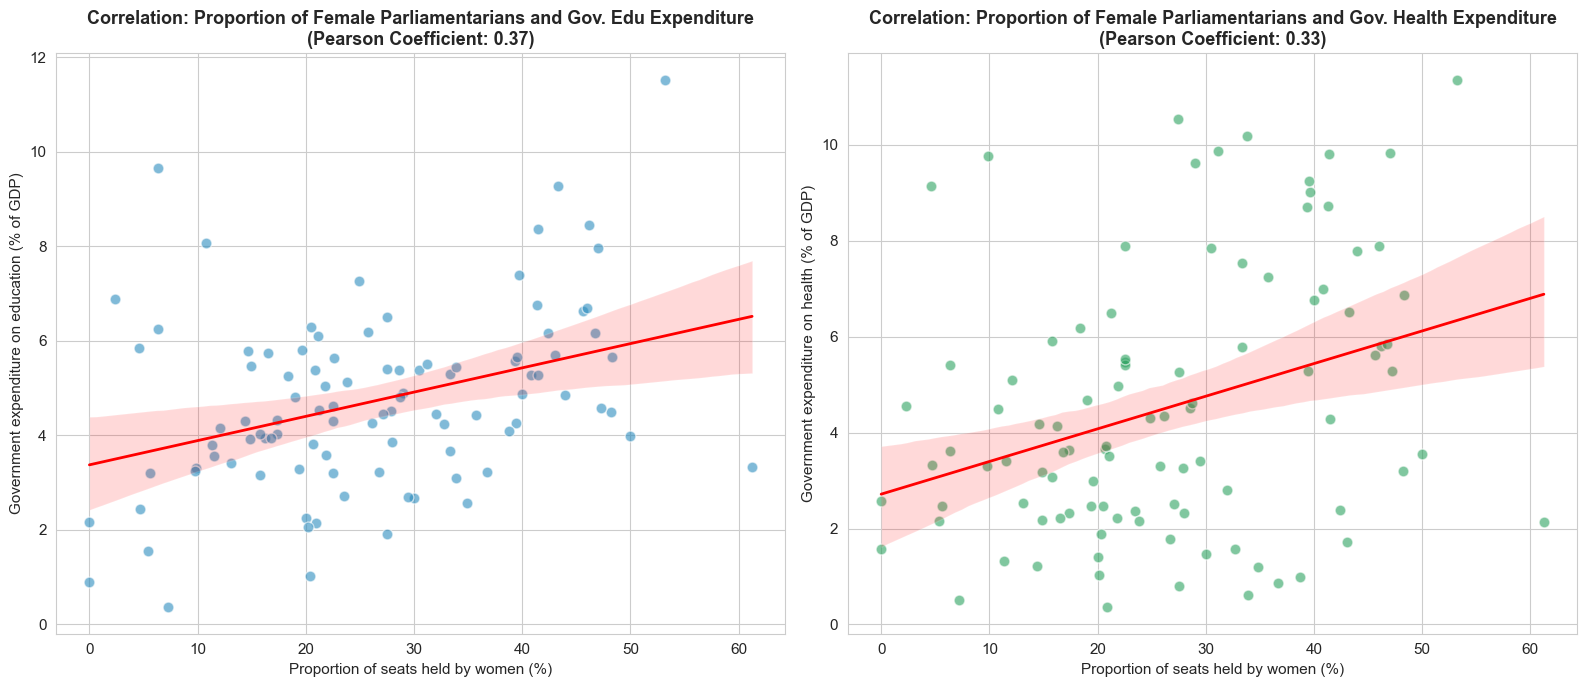

In [ ]:
INDICATORS = {
    'SG.GEN.PARL.ZS': 'Women_in_Parliament',
    'SE.XPD.TOTL.GD.ZS': 'Edu_Expenditure',
    'SH.XPD.GHED.GD.ZS': 'Health_Expenditure'
}

TARGET_YEAR = '2020 [YR2020]'

corr_df = df_raw[df_raw['Series Code'].isin(INDICATORS.keys())].copy()

corr_df = corr_df[['Country Name', 'Country Code', 'Series Code', TARGET_YEAR]]
corr_df.rename(columns={TARGET_YEAR: 'Value'}, inplace=True)

corr_df['Value'] = pd.to_numeric(corr_df['Value'], errors='coerce')

pivot_df = corr_df.pivot(index=['Country Name', 'Country Code'], 
                         columns='Series Code', 
                         values='Value').reset_index()

# Rename Series Codes to understandable names
pivot_df.rename(columns=INDICATORS, inplace=True)

# drop countries missing data in any of the columns
corr_clean = pivot_df.dropna(subset=['Women_in_Parliament', 'Edu_Expenditure', 'Health_Expenditure']).copy()

print(f"Number of countries with complete data for all 3 indicators in 2020: {len(corr_clean)} countries")
corr_clean.head()

plt.figure(figsize=(16, 7))

# Calculate Pearson correlation coefficient
corr_edu = corr_clean['Women_in_Parliament'].corr(corr_clean['Edu_Expenditure'])
corr_health = corr_clean['Women_in_Parliament'].corr(corr_clean['Health_Expenditure'])

# Correlation with Education
plt.subplot(1, 2, 1)
sns.regplot(data=corr_clean, x='Women_in_Parliament', y='Edu_Expenditure', 
            scatter_kws={'alpha':0.6, 'color':'#2b8cbe', 'edgecolor':'w', 's':60}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Correlation: Proportion of Female Parliamentarians and Gov. Edu Expenditure\n(Pearson Coefficient: {corr_edu:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Proportion of seats held by women (%)')
plt.ylabel('Government expenditure on education (% of GDP)')

# Correlation with Healthcare
plt.subplot(1, 2, 2)
sns.regplot(data=corr_clean, x='Women_in_Parliament', y='Health_Expenditure', 
            scatter_kws={'alpha':0.6, 'color':'#2ca25f', 'edgecolor':'w', 's':60}, 
            line_kws={'color':'red', 'linewidth':2})
plt.title(f'Correlation: Proportion of Female Parliamentarians and Gov. Health Expenditure\n(Pearson Coefficient: {corr_health:.2f})', fontsize=13, fontweight='bold')
plt.xlabel('Proportion of seats held by women (%)')
plt.ylabel('Government expenditure on health (% of GDP)')

plt.tight_layout()
plt.show()

#### Conclusion

Based on the 2 scatter plots and regression lines (red) above, our group extracts the following analysis:
* Both plots feature an upward-sloping trendline, and the Pearson coefficients are positive (0.37 and 0.33, respectively), meaning **a positive correlation trend exists**. This initially reinforces the hypothesis: *The higher the proportion of women holding seats in Parliament/National Assembly, the higher the tendency for the national budget allocation (% of GDP) towards social welfare (education and health) to increase.*
* However, **the correlation strength is only at a moderately weak level and has high dispersion**; the data dots (representing countries) are scattered widely across the entire graph space. The confidence interval (pink area) is quite wide, indicating a large variance between countries.
* Comparing the 2 sectors:
    * For **education**: **The correlation is slightly stronger** (Pearson coefficient reaches 0.37). The data tends to cluster more clearly in the middle area (female parliamentary rate of 20-40% corresponding with education spending of 4-6% of GDP).
    * For **healthcare**: **The correlation is weaker** (Pearson coefficient reaches 0.33) and contains many outliers breaking the rule. Specifically, there are countries with very low female representation (under 10%) but massive health budgets (reaching 8-10% of GDP); conversely, many countries have female representation at 20-40%, yet health spending is sluggishly under 2-4% of GDP.

**General Comments**

The charts above provides a realistic view of the national budget problem. The data confirms that: **The presence of women in parliament has a positive impact on human development policies, but it is not the only factor shaping the budget.**

The correlation levels (0.33 and 0.37) show that the voices of female parliamentarians are only a part of the overall picture. In reality, the state budget (especially for healthcare) is heavily influenced by much more urgent factors, for example: an aging population structure, disease risks, the specifics of each country's health insurance system, etc.

**Limitations of the Analysis**

* The chart demonstrates that these two variables increase together, but **it cannot be 100% confirmed that the presence of female parliamentarians has led to increased investment in education/healthcare.** Other specific reasons may exist, for example, the general development of society: A civilized, wealthy society will simultaneously do well in both areas (electing many women to parliament and having sufficient financial resources to spend heavily on social welfare).

* **Spending a large amount of money (% of GDP) does not necessarily guarantee a quality education/healthcare system** if the country manages its budget inefficiently. Similarly, **a large number of female parliamentarians does not necessarily mean they have the power to decide how to allocate the budget**.
